# Pseudospace Reconstruction Method Comparison


# Constructing Pseudospace

In [1]:
# Standard paths, cache directories, analysis libraries, and shared constants.
from pathlib import Path
import os
import warnings

# Put package caches outside the project so plotting/numba setup does not clutter the repo.
CACHE_ROOT = Path('/tmp/pseudospace_method_comparison_cache')
CACHE_ROOT.mkdir(exist_ok=True)
(CACHE_ROOT / 'matplotlib').mkdir(exist_ok=True)
(CACHE_ROOT / 'numba').mkdir(exist_ok=True)
(CACHE_ROOT / 'xdg').mkdir(exist_ok=True)
os.environ.setdefault('NUMBA_CACHE_DIR', str(CACHE_ROOT / 'numba'))
os.environ.setdefault('MPLCONFIGDIR', str(CACHE_ROOT / 'matplotlib'))
os.environ.setdefault('XDG_CACHE_HOME', str(CACHE_ROOT / 'xdg'))

# Scientific Python stack used throughout the notebook.
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.stats import spearmanr
from IPython.display import display

sc.settings.verbosity = 2
sns.set_theme(style='whitegrid', context='notebook')
warnings.filterwarnings('ignore', category=FutureWarning)

# Project paths and output locations.
PROJECT_DIR = Path.cwd().resolve()
DATA_DIR = PROJECT_DIR / 'data'
HARMONY_PATH = DATA_DIR / 'all_tubules_harmony_ortholog_space.h5ad'
OUTPUT_DIR = DATA_DIR / 'pseudspace_analysis'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Local R library for optional Slingshot and Monocle3 dependencies.
R_LIB_DIR = PROJECT_DIR / '.r_libs'
R_LIB_DIR.mkdir(exist_ok=True)
os.environ.setdefault('R_LIBS_USER', str(R_LIB_DIR))

# Shared analysis parameters and helpers.
RANDOM_STATE = 0
MAX_R_METHOD_CELLS = None  # Use all tubules for R-based methods.
N_NEIGHBORS = 30
N_PCS_FALLBACK = 30
N_DIFFMAP_COMPONENTS_TO_TEST = 8
CONTINUA_TO_RUN = ['TOTAL', 'PT', 'TAL', 'DCT']

print(f'Harmony input: {HARMONY_PATH}')
print(f'Output directory: {OUTPUT_DIR}')


# Marker panels used to assign each tubule to a broad nephron family.
BROAD_SEGMENT_MARKERS = {
    'PT': ['Slc34a1', 'Lrp2', 'Slc5a12', 'Slc13a3', 'Slc22a6', 'Slc22a7', 'Aqp1'],
    'TL': ['Aqp1', 'Cldn4', 'Id1', 'Jag1', 'Vcam1', 'Tacstd2', 'Akr1b1'],
    'TAL': ['Umod', 'Slc12a1', 'Cldn10', 'Egf', 'Bcl6'],
    'DCT': ['Slc12a3', 'Calb1', 'Pvalb', 'Hsd11b2'],
    'CNT_CD': ['Calb1', 'Aqp2', 'Aqp3', 'Itpkb', 'Fxyd4', 'Slc4a1', 'Slc26a4', 'Atp6v1b1'],
}

# Per-continuum settings: subset, expected order, marker panels, and plotting colors.
CONTINUUM_CONFIGS = {
    'TOTAL': {
        'prefix': 'total',
        'subset_family': None,
        'segment_order': ['PT', 'TL', 'TAL', 'DCT', 'CNT_CD'],
        'segment_markers': BROAD_SEGMENT_MARKERS,
        'position_markers': {
            'early': ['Slc34a1', 'Lrp2', 'Slc5a2', 'Slc5a12'],
            'late': ['Aqp2', 'Aqp3', 'Slc4a1', 'Slc26a4', 'Atp6v1b1'],
        },
        'palette': {'PT': '#4C78A8', 'TL': '#B279A2', 'TAL': '#F58518', 'DCT': '#54A24B', 'CNT_CD': '#E45756'},
    },
    'PT': {
        'prefix': 'pt',
        'subset_family': 'PT',
        'segment_order': ['PT_S1', 'PT_S2', 'PT_S3'],
        'segment_markers': {
            'PT_S1': ['Slc5a2', 'Slc5a12'],
            'PT_S2': ['Slc22a8', 'Slc22a6', 'Slc13a3', 'Slc22a2', 'Slc34a1'],
            'PT_S3': ['Slc7a13', 'Slc5a8', 'Slc38a3', 'Hao2', 'Pck1', 'Acsm3'],
        },
        'position_markers': {
            'early': ['Slc5a2', 'Slc5a12', 'Slc22a8'],
            'late': ['Slc7a13', 'Slc5a8', 'Slc38a3', 'Hao2', 'Pck1', 'Acsm3'],
        },
        'palette': {'PT_S1': '#4C78A8', 'PT_S2': '#F58518', 'PT_S3': '#54A24B'},
    },
    'TAL': {
        'prefix': 'tal',
        'subset_family': 'TAL',
        'segment_order': ['M_TAL', 'C_TAL'],
        'segment_markers': {
            'M_TAL': ['Umod', 'Slc12a1', 'Kcnj1', 'Egf'],
            'C_TAL': ['Cldn10', 'Bcl6', 'Nos1'],
        },
        'position_markers': {
            'early': ['Slc12a1', 'Kcnj1', 'Egf'],
            'late': ['Nos1', 'Bcl6'],
        },
        'palette': {'M_TAL': '#4C78A8', 'C_TAL': '#F58518'},
    },
    'DCT': {
        'prefix': 'dct',
        'subset_family': 'DCT',
        'segment_order': ['DCT1', 'DCT2'],
        'segment_markers': {
            'DCT1': ['Slc12a3', 'Pvalb'],
            'DCT2': ['Hsd11b2', 'Scnn1g', 'Calb1'],
        },
        'position_markers': {
            'early': ['Slc12a3', 'Pvalb'],
            'late': ['Hsd11b2', 'Scnn1g'],
        },
        'palette': {'DCT1': '#4C78A8', 'DCT2': '#F58518'},
    },
}

# One-time preprocessing parameters.
MIN_GENE_TUBULE_FRACTION = 0.05
MIN_GENE_TOTAL_COUNTS = 20
NORMALIZE_TARGET_SUM = 1e4
N_HVGS = 3000
REMOVE_MITO_RIBO_STRESS_GENES = False
EXCLUDE_VALIDATION_MARKERS = False

STRESS_GENE_PREFIXES = ('FOS', 'JUN', 'HSP', 'DNAJ')



Harmony input: /home/edmund/Desktop/pseudospace_reconstruction/data/all_tubules_harmony_ortholog_space.h5ad
Output directory: /home/edmund/Desktop/pseudospace_reconstruction/data/pseudspace_analysis


## Filtering and Normalization


> **Filtering and normalization notes**
>
> The notebook loads the harmonized all-tubules AnnData object once, preserves the raw-count matrix in `layers['counts']`, and uses that same filtered matrix for all pseudotime methods.
>
> Genes are kept if they are expressed in at least `MIN_GENE_TUBULE_FRACTION` of tubules, currently 5%, and have at least `MIN_GENE_TOTAL_COUNTS` total counts, currently 20. The retained count matrix is then normalized with `sc.pp.normalize_total(target_sum=1e4)` and log-transformed with `sc.pp.log1p`; the result is stored in `layers['lognorm']`.
>
> Feature selection runs HVG selection on the tubule-level log-normalized matrix with up to `N_HVGS` genes, currently 3000. Validation markers are retained by default even if they are not HVGs. Optional switches can remove mitochondrial/ribosomal/stress genes or exclude validation markers for sensitivity analysis.


In [2]:
# Load once, preserve raw counts, filter genes, normalize/log-transform, and prepare continua.
adata_all = sc.read_h5ad(HARMONY_PATH)
print(f'Loaded harmonized object: {adata_all.n_obs:,} tubules x {adata_all.n_vars:,} genes')

if 'counts' in adata_all.layers:
    counts = adata_all.layers['counts'].copy()
else:
    counts = adata_all.X.copy()
    print('No counts layer found; using current X as the raw-count source')
adata_all.layers['counts'] = counts.copy()
adata_all.uns['raw_counts_layer'] = 'counts'

counts_matrix = counts if sparse.issparse(counts) else np.asarray(counts)
expressed = np.asarray((counts_matrix > 0).sum(axis=0)).ravel()
total_counts = np.asarray(counts_matrix.sum(axis=0)).ravel()
min_cells = max(1, int(np.ceil(MIN_GENE_TUBULE_FRACTION * adata_all.n_obs)))
gene_keep = (expressed >= min_cells) & (total_counts >= MIN_GENE_TOTAL_COUNTS)
adata_all.var['n_tubules_expressed'] = expressed
adata_all.var['total_counts'] = total_counts
adata_all.var['passes_expression_count_filter'] = gene_keep
print(f'Gene filter keeps {int(gene_keep.sum()):,}/{adata_all.n_vars:,} genes '
      f'(expressed in >= {MIN_GENE_TUBULE_FRACTION:.0%} tubules and total counts >= {MIN_GENE_TOTAL_COUNTS})')
adata_all = adata_all[:, gene_keep].copy()

# Normalize every method from the same filtered raw-count matrix.
adata_all.X = adata_all.layers['counts'].copy()
sc.pp.normalize_total(adata_all, target_sum=NORMALIZE_TARGET_SUM)
sc.pp.log1p(adata_all)
adata_all.layers['lognorm'] = adata_all.X.copy()
adata_all.uns['normalization'] = {'method': 'normalize_total_log1p', 'target_sum': NORMALIZE_TARGET_SUM}

# Preserve the full expression-filtered matrix for final saved AnnData outputs.
adata_all_expression_filtered = adata_all.copy()

# Build a case-insensitive gene lookup that also checks common gene-symbol alias columns.
def build_gene_lookup(adata):
    var_names = pd.Index(adata.var_names.astype(str))
    lookup = {name.upper(): name for name in var_names}
    for alias_col in ['gene_symbol', 'gene_symbols', 'symbol', 'gene_name', 'feature_name', 'features']:
        if alias_col in adata.var.columns:
            for idx_name, alias in zip(var_names, adata.var[alias_col].astype(str)):
                alias_upper = alias.upper()
                if alias_upper and alias_upper != 'NAN' and alias_upper not in lookup:
                    lookup[alias_upper] = idx_name
    return lookup

gene_lookup = build_gene_lookup(adata_all)
validation_markers = sorted(set(
    marker
    for config in CONTINUUM_CONFIGS.values()
    for marker_sets in [config['segment_markers'], config['position_markers']]
    for genes in marker_sets.values()
    for marker in genes
))
validation_genes = {gene_lookup[g.upper()] for g in validation_markers if g.upper() in gene_lookup}

if REMOVE_MITO_RIBO_STRESS_GENES:
    upper_names = pd.Index(adata_all.var_names.astype(str).str.upper())
    optional_exclude = (
        upper_names.str.startswith(('MT-', 'MT.'))
        | upper_names.str.startswith(('RPS', 'RPL'))
        | upper_names.map(lambda name: name.startswith(STRESS_GENE_PREFIXES))
    ).to_numpy(dtype=bool)
else:
    optional_exclude = np.zeros(adata_all.n_vars, dtype=bool)
adata_all.var['excluded_optional_gene'] = optional_exclude
if optional_exclude.any():
    adata_all = adata_all[:, ~optional_exclude].copy()
    gene_lookup = build_gene_lookup(adata_all)
    validation_genes = {gene_lookup[g.upper()] for g in validation_markers if g.upper() in gene_lookup}

# Select HVGs on tubule-level expression, retaining validation markers unless sensitivity mode excludes them.
sc.pp.highly_variable_genes(adata_all, n_top_genes=min(N_HVGS, adata_all.n_vars), flavor='seurat')
validation_mask = adata_all.var_names.isin(validation_genes)
feature_keep = adata_all.var['highly_variable'].to_numpy(dtype=bool)
if EXCLUDE_VALIDATION_MARKERS:
    feature_keep = feature_keep & ~validation_mask
else:
    feature_keep = feature_keep | validation_mask
adata_all.var['selected_for_pseudotime'] = feature_keep
print(f'Feature selection keeps {int(feature_keep.sum()):,}/{adata_all.n_vars:,} genes '
      f'({int(adata_all.var["highly_variable"].sum()):,} HVGs; '
      f'{int(validation_mask.sum()):,} validation markers available)')
adata_all = adata_all[:, feature_keep].copy()
gene_lookup = build_gene_lookup(adata_all)

# Assign broad tubule families if the harmonized object does not already contain them.
family_col = 'broad_tubule_marker_call'
if family_col not in adata_all.obs.columns:
    score_cols = []
    for segment, marker_genes in BROAD_SEGMENT_MARKERS.items():
        genes = [gene_lookup[g.upper()] for g in marker_genes if g.upper() in gene_lookup]
        if not genes:
            continue
        score_col = f'{segment}_broad_score'
        sc.tl.score_genes(adata_all, genes, score_name=score_col, use_raw=False)
        score_cols.append(score_col)
    if not score_cols:
        raise ValueError('No broad family markers were found in the filtered matrix')
    scores = adata_all.obs[score_cols].astype(float)
    calls = scores.idxmax(axis=1).str.replace('_broad_score', '', regex=False)
    adata_all.obs[family_col] = pd.Categorical(calls, categories=list(BROAD_SEGMENT_MARKERS), ordered=True)

display(adata_all.obs[family_col].value_counts(dropna=False))

# Create one filtered AnnData object per continuum for all downstream pseudotime methods.
preprocessed_loaded = {}
for continuum in CONTINUA_TO_RUN:
    print('\n' + '=' * 80)
    print(f'Preparing {continuum}')
    config = CONTINUUM_CONFIGS[continuum]
    prefix = config['prefix']

    if config['subset_family'] is None:
        adata = adata_all.copy()
    else:
        mask = adata_all.obs[family_col].astype(str) == config['subset_family']
        adata = adata_all[mask].copy()
        if adata.n_obs == 0:
            raise ValueError(f"No cells were assigned to broad family {config['subset_family']}")
    print(f'Subset size: {adata.n_obs:,} tubules')

    expected_rows = []
    for role in ['early', 'late']:
        requested = config['position_markers'][role]
        genes = [gene_lookup[g.upper()] for g in requested if g.upper() in gene_lookup]
        missing = [g for g in requested if g.upper() not in gene_lookup]
        print(f'{prefix} {role} markers present ({len(genes)}/{len(requested)}): {genes}')
        if missing:
            print(f'  missing {role}: {missing}')
        if not genes:
            raise ValueError(f'No {role} position markers found for {prefix}')
        score_col = f'{prefix}_{role}_trajectory_score'
        sc.tl.score_genes(adata, genes, score_name=score_col, use_raw=False)
        for gene in genes:
            expected_rows.append({
                'gene': gene,
                'role': role,
                'expected_sign': -1 if role == 'early' else 1,
                'expected_direction': 'early-high' if role == 'early' else 'late-high',
            })

    marker_axis = adata.obs[f'{prefix}_late_trajectory_score'].astype(float) - adata.obs[f'{prefix}_early_trajectory_score'].astype(float)
    adata.obs[f'{prefix}_marker_axis'] = marker_axis
    marker_values = marker_axis.to_numpy(dtype=float)
    finite = np.isfinite(marker_values)
    normalized = np.full(marker_values.shape, np.nan, dtype=float)
    if finite.sum() > 0:
        p5, p95 = np.nanpercentile(marker_values[finite], [5, 95])
        normalized[finite] = np.clip((marker_values[finite] - p5) / max(p95 - p5, 1e-8), 0, 1)
    adata.obs[f'{prefix}_marker_axis_pseudotime'] = normalized

    saved_ps_col = f'{prefix}_pseudospace'
    if saved_ps_col not in adata.obs.columns:
        existing = next((col for col in ['pseudospace', f'{prefix}_position_percentile'] if col in adata.obs.columns), None)
        adata.obs[saved_ps_col] = pd.to_numeric(adata.obs[existing], errors='coerce') if existing is not None else adata.obs[f'{prefix}_marker_axis_pseudotime']

    marker_call_col = f'{prefix}_segment_marker_call'
    if marker_call_col not in adata.obs.columns:
        score_cols = []
        for segment, marker_genes in config['segment_markers'].items():
            genes = [gene_lookup[g.upper()] for g in marker_genes if g.upper() in gene_lookup]
            if not genes:
                continue
            score_col = f'{segment}_trajectory_compare_score'
            sc.tl.score_genes(adata, genes, score_name=score_col, use_raw=False)
            score_cols.append(score_col)
        if score_cols:
            scores = adata.obs[score_cols].astype(float)
            calls = scores.idxmax(axis=1).str.replace('_trajectory_compare_score', '', regex=False)
            adata.obs[marker_call_col] = pd.Categorical(calls, categories=config['segment_order'], ordered=True)

    method_cols = []
    method_notes = {}

    col = f'{prefix}_marker_axis_score'
    adata.obs[col] = adata.obs[f'{prefix}_marker_axis_pseudotime'].to_numpy(dtype=float)
    method_cols.append(col)
    method_notes[col] = 'marker-axis reference from early and late marker scores'

    values = adata.obs[saved_ps_col].to_numpy(dtype=float)
    reference = adata.obs[f'{prefix}_marker_axis'].to_numpy(dtype=float)
    valid = np.isfinite(values) & np.isfinite(reference)
    oriented = values.copy()
    if valid.sum() >= 10:
        corr = spearmanr(oriented[valid], reference[valid]).correlation
        if np.isfinite(corr) and corr < 0:
            oriented = -oriented
    finite = np.isfinite(oriented)
    normalized = np.full(oriented.shape, np.nan, dtype=float)
    if finite.sum() > 0:
        p5, p95 = np.nanpercentile(oriented[finite], [5, 95])
        normalized[finite] = np.clip((oriented[finite] - p5) / max(p95 - p5, 1e-8), 0, 1)
    col = f'{prefix}_saved_marker_pseudospace'
    adata.obs[col] = normalized
    method_cols.append(col)
    method_notes[col] = 'saved marker-derived pseudospace oriented to marker axis'

    preprocessed_loaded[continuum] = {
        'adata': adata,
        'config': config,
        'expected_markers': pd.DataFrame(expected_rows).drop_duplicates('gene').reset_index(drop=True),
        'method_cols': method_cols,
        'method_notes': method_notes,
    }


def clone_preprocessed_continua():
    cloned = {}
    for continuum, obj in preprocessed_loaded.items():
        cloned[continuum] = {
            'adata': obj['adata'].copy(),
            'config': obj['config'],
            'expected_markers': obj['expected_markers'].copy(),
            'method_cols': obj['method_cols'][:],
            'method_notes': obj['method_notes'].copy(),
        }
    return cloned


Loaded harmonized object: 45,753 tubules x 15,736 genes
Gene filter keeps 9,610/15,736 genes (expressed in >= 5% tubules and total counts >= 20)
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
Feature selection keeps 3,007/9,610 genes (3,000 HVGs; 38 validation markers available)
computing score 'PT_broad_score'
    finished (0:00:00)
computing score 'TL_broad_score'
    finished (0:00:00)
computing score 'TAL_broad_score'
    finished (0:00:00)
computing score 'DCT_broad_score'
    finished (0:00:00)
computing score 'CNT_CD_broad_score'
    finished (0:00:00)


broad_tubule_marker_call
PT        20405
TAL       14472
DCT        4468
TL         3214
CNT_CD     3194
Name: count, dtype: int64


Preparing TOTAL
Subset size: 45,753 tubules
total early markers present (4/4): ['Slc34a1', 'Lrp2', 'Slc5a2', 'Slc5a12']
computing score 'total_early_trajectory_score'
    finished (0:00:00)
total late markers present (5/5): ['Aqp2', 'Aqp3', 'Slc4a1', 'Slc26a4', 'Atp6v1b1']
computing score 'total_late_trajectory_score'
    finished (0:00:00)
computing score 'PT_trajectory_compare_score'
    finished (0:00:00)
computing score 'TL_trajectory_compare_score'
    finished (0:00:00)
computing score 'TAL_trajectory_compare_score'
    finished (0:00:00)
computing score 'DCT_trajectory_compare_score'
    finished (0:00:00)
computing score 'CNT_CD_trajectory_compare_score'
    finished (0:00:00)

Preparing PT
Subset size: 20,405 tubules
pt early markers present (3/3): ['Slc5a2', 'Slc5a12', 'Slc22a8']
computing score 'pt_early_trajectory_score'
    finished (0:00:00)
pt late markers present (6/6): ['Slc7a13', 'Slc5a8', 'Slc38a3', 'Hao2', 'Pck1', 'Acsm3']
computing score 'pt_late_trajectory_score'

## PAGA Analysis



Running PAGA topology check for TOTAL
total: PAGA neighbor graph uses representation X_harmony
computing neighbors


/home/edmund/ENTER/envs/tubule_pseudospace_reconstruction/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished (0:00:21)
running PAGA
    finished (0:00:00)


,PT,TL,TAL,DCT,CNT_CD
PT,0.000,0.319,0.168,0.167,0.221
TL,0.319,0.000,0.687,0.669,1.000
TAL,0.168,0.687,0.000,0.197,0.467
DCT,0.167,0.669,0.197,0.000,1.000
CNT_CD,0.221,1.000,0.467,1.000,0.000


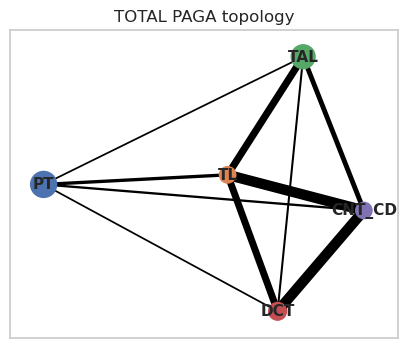


Running PAGA topology check for PT
pt: PAGA neighbor graph uses representation X_harmony
computing neighbors
    finished (0:00:03)
running PAGA
    finished (0:00:00)


,PT_S1,PT_S2,PT_S3
PT_S1,0.000,0.590,0.166
PT_S2,0.590,0.000,0.782
PT_S3,0.166,0.782,0.000


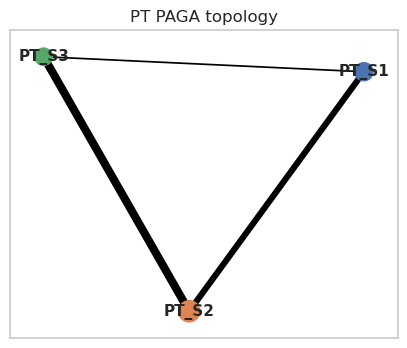


Running PAGA topology check for TAL
tal: PAGA neighbor graph uses representation X_harmony
computing neighbors
    finished (0:00:02)
running PAGA
    finished (0:00:00)


,M_TAL,C_TAL
M_TAL,0.000,0.716
C_TAL,0.716,0.000


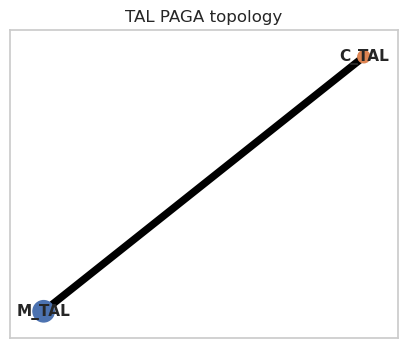


Running PAGA topology check for DCT
dct: PAGA neighbor graph uses representation X_harmony
computing neighbors
    finished (0:00:00)
running PAGA
    finished (0:00:00)


,DCT1,DCT2
DCT1,0.000,0.301
DCT2,0.301,0.000


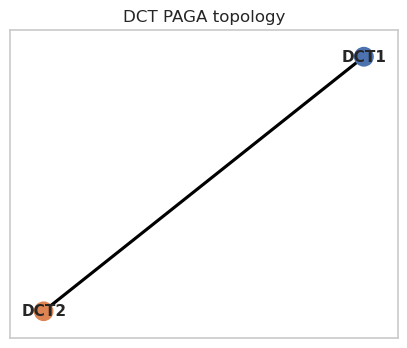

,continuum,edge_type,left_group,right_group,paga_connectivity
9,DCT,expected_adjacent,DCT1,DCT2,0.300629
6,PT,expected_adjacent,PT_S2,PT_S3,0.781988
5,PT,expected_adjacent,PT_S1,PT_S2,0.589868
7,PT,strongest_nonadjacent,PT_S1,PT_S3,0.166259
8,TAL,expected_adjacent,M_TAL,C_TAL,0.715654
3,TOTAL,expected_adjacent,DCT,CNT_CD,1.000000
1,TOTAL,expected_adjacent,TL,TAL,0.686691
0,TOTAL,expected_adjacent,PT,TL,0.318560
2,TOTAL,expected_adjacent,TAL,DCT,0.197160
4,TOTAL,strongest_nonadjacent,TL,CNT_CD,1.000000


In [3]:
# Use PAGA to check whether marker-defined discrete clusters form the expected topology.
paga_topology_rows = []

for continuum, obj in preprocessed_loaded.items():
    print('\n' + '=' * 80)
    print(f'Running PAGA topology check for {continuum}')
    adata = obj['adata']
    config = obj['config']
    prefix = config['prefix']
    cluster_col = f'{prefix}_segment_marker_call'

    if cluster_col not in adata.obs.columns:
        print(f'Skipped PAGA for {continuum}: missing {cluster_col}')
        continue

    labels = adata.obs[cluster_col].astype(str).replace({'nan': 'unassigned', 'None': 'unassigned'})
    present = pd.Index(labels.unique())
    group_order = [group for group in config['segment_order'] if group in present]
    group_order += sorted([group for group in present if group not in group_order])
    if len(group_order) < 2:
        print(f'Skipped PAGA for {continuum}: fewer than two discrete groups')
        continue
    paga_group_col = f'{prefix}_paga_group'
    adata.obs[paga_group_col] = pd.Categorical(labels, categories=group_order, ordered=True)

    preferred_reps = [
        f'X_pca_harmony_{prefix}',
        f'X_umap_harmony_{prefix}',
        'X_pca_harmony',
        'X_harmony',
        'X_pca',
    ]
    use_rep = next((rep for rep in preferred_reps if rep in adata.obsm), None)
    if use_rep is None:
        sc.pp.pca(adata, n_comps=min(N_PCS_FALLBACK, adata.n_vars - 1), random_state=RANDOM_STATE)
        use_rep = 'X_pca'
    print(f'{prefix}: PAGA neighbor graph uses representation {use_rep}')

    neighbors_key = f'{prefix}_paga_neighbors'
    paga_key = f'{prefix}_paga'
    sc.pp.neighbors(adata, n_neighbors=N_NEIGHBORS, use_rep=use_rep, key_added=neighbors_key, random_state=RANDOM_STATE)
    sc.tl.paga(adata, groups=paga_group_col, neighbors_key=neighbors_key, copy=False)
    adata.uns[paga_key] = adata.uns['paga'].copy()

    connectivities = adata.uns[paga_key]['connectivities']
    dense = connectivities.toarray() if sparse.issparse(connectivities) else np.asarray(connectivities)
    conn_df = pd.DataFrame(dense, index=group_order, columns=group_order)
    display(conn_df.round(3))

    expected_edges = list(zip(config['segment_order'][:-1], config['segment_order'][1:]))
    for left, right in expected_edges:
        if left not in conn_df.index or right not in conn_df.columns:
            continue
        connection = float(conn_df.loc[left, right])
        paga_topology_rows.append({
            'continuum': continuum,
            'edge_type': 'expected_adjacent',
            'left_group': left,
            'right_group': right,
            'paga_connectivity': connection,
        })

    expected_sets = {frozenset(edge) for edge in expected_edges}
    nonadjacent_rows = []
    for i, left in enumerate(group_order):
        for right in group_order[i + 1:]:
            if frozenset([left, right]) in expected_sets:
                continue
            nonadjacent_rows.append((left, right, float(conn_df.loc[left, right])))
    if nonadjacent_rows:
        left, right, connection = max(nonadjacent_rows, key=lambda row: row[2])
        paga_topology_rows.append({
            'continuum': continuum,
            'edge_type': 'strongest_nonadjacent',
            'left_group': left,
            'right_group': right,
            'paga_connectivity': connection,
        })

    fig, ax = plt.subplots(figsize=(5, 4))
    sc.pl.paga(
        adata,
        threshold=0.03,
        color=paga_group_col,
        title=f'{continuum} PAGA topology',
        show=False,
        ax=ax,
    )
    plt.show()

paga_topology_summary = pd.DataFrame(paga_topology_rows)
if not paga_topology_summary.empty:
    display(paga_topology_summary.sort_values(['continuum', 'edge_type', 'paga_connectivity'], ascending=[True, True, False]))
else:
    print('No PAGA topology summaries were generated')


## Method 1: Diffusion Pseudotime



Running Scanpy diffusion pseudotime for TOTAL
total: neighbor graph uses representation X_harmony
computing neighbors
    finished (0:00:06)
computing Diffusion Maps using n_comps=15(=n_dcs)
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         0.9924646  0.98994136 0.98366284 0.975218   0.9681613
     0.95071876 0.9479061  0.9433729  0.93326765 0.9298312  0.9252781
     0.9208646  0.9196324  0.91811407]
    finished (0:00:03)


,component,spearman_with_marker_axis
0,0,-0.039599
1,1,0.804268
2,2,-0.372871
3,3,-0.034855
4,4,0.207748
5,5,0.083723
6,6,-0.069344
7,7,0.065781


computing Diffusion Pseudotime using n_dcs=10
    finished (0:00:00)


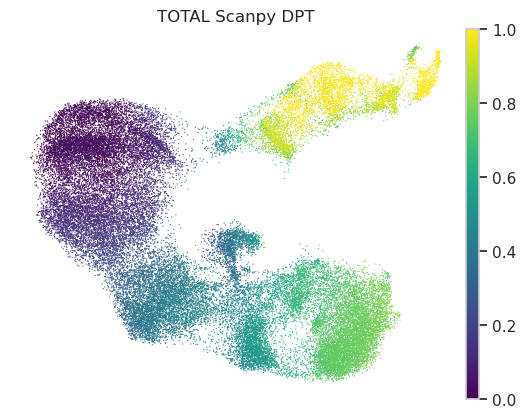

In [4]:
dpt_base_loaded = clone_preprocessed_continua()
dpt_loaded = {'TOTAL': dpt_base_loaded['TOTAL']}
dpt_adata_all = adata_all.copy()

# Run Scanpy diffusion map and DPT once on the total pseudospace.
for continuum, obj in dpt_loaded.items():
    print('\n' + '=' * 80)
    print(f'Running Scanpy diffusion pseudotime for {continuum}')
    adata = obj['adata']
    config = obj['config']
    prefix = config['prefix']
    marker_axis = adata.obs[f'{prefix}_marker_axis'].to_numpy(dtype=float)

    # Prefer harmonized embeddings; compute PCA only if no suitable representation exists.
    preferred_reps = [
        f'X_pca_harmony_{prefix}',
        f'X_umap_harmony_{prefix}',
        'X_pca_harmony',
        'X_harmony',
        'X_pca',
    ]
    use_rep = next((rep for rep in preferred_reps if rep in adata.obsm), None)
    if use_rep is None:
        sc.pp.pca(adata, n_comps=min(N_PCS_FALLBACK, adata.n_vars - 1), random_state=RANDOM_STATE)
        use_rep = 'X_pca'
    print(f'{prefix}: neighbor graph uses representation {use_rep}')

    # Build the neighbor graph used by both diffusion map and DPT.
    neighbors_key = 'trajectory_compare_neighbors'
    sc.pp.neighbors(adata, n_neighbors=N_NEIGHBORS, use_rep=use_rep, key_added=neighbors_key, random_state=RANDOM_STATE)
    sc.tl.diffmap(adata, neighbors_key=neighbors_key)

    # Find which diffusion component best follows the marker-defined direction.
    component_rows = []
    n_components = min(N_DIFFMAP_COMPONENTS_TO_TEST, adata.obsm['X_diffmap'].shape[1])
    for i in range(n_components):
        values = adata.obsm['X_diffmap'][:, i].astype(float)
        valid = np.isfinite(values) & np.isfinite(marker_axis)
        corr = spearmanr(values[valid], marker_axis[valid]).correlation if valid.sum() >= 10 else np.nan
        component_rows.append({'component': i, 'spearman_with_marker_axis': corr})
    component_df = pd.DataFrame(component_rows)
    display(component_df)

    # Keep the most marker-aligned diffusion component as a comparable pseudotime-like coordinate.
    best_row = component_df.iloc[component_df['spearman_with_marker_axis'].abs().fillna(-1).argmax()]
    best_component = int(best_row['component'])
    values = adata.obsm['X_diffmap'][:, best_component].astype(float)
    valid = np.isfinite(values) & np.isfinite(marker_axis)
    oriented = values.copy()
    if valid.sum() >= 10:
        corr = spearmanr(oriented[valid], marker_axis[valid]).correlation
        if np.isfinite(corr) and corr < 0:
            oriented = -oriented
    finite = np.isfinite(oriented)
    normalized = np.full(oriented.shape, np.nan, dtype=float)
    if finite.sum() > 0:
        p5, p95 = np.nanpercentile(oriented[finite], [5, 95])
        normalized[finite] = np.clip((oriented[finite] - p5) / max(p95 - p5, 1e-8), 0, 1)
    col = f'{prefix}_diffmap_component_{best_component}'
    adata.obs[col] = normalized
    obj['method_cols'].append(col)
    obj['method_notes'][col] = f'Scanpy diffusion map component {best_component}, oriented to marker axis'

    # Root DPT at the cell with the lowest marker-axis value, representing the earliest state.
    root_candidates = np.where(np.isfinite(marker_axis))[0]
    adata.uns['iroot'] = int(root_candidates[np.nanargmin(marker_axis[root_candidates])])
    sc.tl.dpt(adata, neighbors_key=neighbors_key)

    # Orient and normalize DPT so all methods share a 0-to-1 early-to-late scale.
    values = adata.obs['dpt_pseudotime'].to_numpy(dtype=float)
    valid = np.isfinite(values) & np.isfinite(marker_axis)
    oriented = values.copy()
    if valid.sum() >= 10:
        corr = spearmanr(oriented[valid], marker_axis[valid]).correlation
        if np.isfinite(corr) and corr < 0:
            oriented = -oriented
    finite = np.isfinite(oriented)
    normalized = np.full(oriented.shape, np.nan, dtype=float)
    if finite.sum() > 0:
        p5, p95 = np.nanpercentile(oriented[finite], [5, 95])
        normalized[finite] = np.clip((oriented[finite] - p5) / max(p95 - p5, 1e-8), 0, 1)
    col = f'{prefix}_scanpy_dpt'
    adata.obs[col] = normalized
    obj['method_cols'].append(col)
    obj['method_notes'][col] = f'Scanpy DPT on {use_rep}, rooted at lowest marker-axis cell'

# Plot total diffusion pseudotime on the available UMAP embedding.
total_obj = dpt_loaded['TOTAL']
total_adata = total_obj['adata']
total_dpt_col = 'total_scanpy_dpt'

basis = None
for key in ['X_umap_harmony_total', 'X_umap_harmony', 'X_umap']:
    if key in total_adata.obsm:
        basis = key.replace('X_', '', 1)
        break
if basis is None:
    for key in total_adata.obsm.keys():
        if str(key).startswith('X_umap'):
            basis = str(key).replace('X_', '', 1)
            break
if basis is None:
    sc.tl.umap(total_adata, neighbors_key='trajectory_compare_neighbors', random_state=RANDOM_STATE)
    basis = 'umap'

sc.pl.embedding(
    total_adata,
    basis=basis,
    color=total_dpt_col,
    cmap='viridis',
    frameon=False,
    na_color='lightgray',
    size=8 if total_adata.n_obs < 5000 else 3,
    title='TOTAL Scanpy DPT',
)



> **Marker trend plot notes**
>
> Points are not evenly spaced by bin number. Cells are split into quantile bins along `total_scanpy_dpt`, so each bin contains roughly the same number of tubules. Each plotted point is placed at that bin's mean DPT value, which means points are closer together where many tubules occupy a narrow DPT range and farther apart where a bin spans a wider DPT interval.
>
> Error bars show the standard error of the mean across marker genes within the same marker panel at each DPT bin, after each gene's binned expression curve is min-max normalized. They summarize marker-to-marker variability within a panel, not uncertainty across individual tubules. Panels with one available marker gene have zero-width error bars.


,marker_panel,requested_gene,gene,present,view,method
0,PT,Slc34a1,Slc34a1,True,broad_nephron,TOTAL Scanpy DPT
1,PT,Lrp2,Lrp2,True,broad_nephron,TOTAL Scanpy DPT
2,PT,Slc5a12,Slc5a12,True,broad_nephron,TOTAL Scanpy DPT
3,PT,Slc13a3,Slc13a3,True,broad_nephron,TOTAL Scanpy DPT
4,PT,Slc22a6,Slc22a6,True,broad_nephron,TOTAL Scanpy DPT
5,PT,Slc22a7,Slc22a7,True,broad_nephron,TOTAL Scanpy DPT
6,PT,Aqp1,Aqp1,True,broad_nephron,TOTAL Scanpy DPT
7,TAL,Umod,Umod,True,broad_nephron,TOTAL Scanpy DPT
8,TAL,Slc12a1,Slc12a1,True,broad_nephron,TOTAL Scanpy DPT
9,TAL,Cldn10,Cldn10,True,broad_nephron,TOTAL Scanpy DPT


,marker_panel,requested_gene,gene,present,view,method
0,PT_S1,Slc5a2,Slc5a2,True,PT_zoom,TOTAL Scanpy DPT
1,PT_S1,Slc5a12,Slc5a12,True,PT_zoom,TOTAL Scanpy DPT
2,PT_S2,Slc22a8,Slc22a8,True,PT_zoom,TOTAL Scanpy DPT
3,PT_S2,Slc22a6,Slc22a6,True,PT_zoom,TOTAL Scanpy DPT
4,PT_S2,Slc13a3,Slc13a3,True,PT_zoom,TOTAL Scanpy DPT
5,PT_S2,Slc22a2,Slc22a2,True,PT_zoom,TOTAL Scanpy DPT
6,PT_S2,Slc34a1,Slc34a1,True,PT_zoom,TOTAL Scanpy DPT
7,PT_S3,Slc7a13,Slc7a13,True,PT_zoom,TOTAL Scanpy DPT
8,PT_S3,Slc5a8,Slc5a8,True,PT_zoom,TOTAL Scanpy DPT
9,PT_S3,Slc38a3,Slc38a3,True,PT_zoom,TOTAL Scanpy DPT


,marker_panel,gene,peak_pseudotime,peak_mean_expression,normalized_expression,view,method
0,PT_S1,Slc5a2,0.000186,2.256039,1.0,PT_zoom,TOTAL Scanpy DPT
1,PT_S1,Slc5a12,0.005658,2.406212,1.0,PT_zoom,TOTAL Scanpy DPT
2,PT_S2,Slc22a8,0.015844,2.259512,1.0,PT_zoom,TOTAL Scanpy DPT
3,PT_S2,Slc34a1,0.085703,3.263762,1.0,PT_zoom,TOTAL Scanpy DPT
4,PT_S2,Slc22a6,0.115700,2.261837,1.0,PT_zoom,TOTAL Scanpy DPT
5,PT_S2,Slc13a3,0.123611,2.063144,1.0,PT_zoom,TOTAL Scanpy DPT
6,PT_S2,Slc22a2,0.141038,1.426067,1.0,PT_zoom,TOTAL Scanpy DPT
7,PT_S3,Pck1,0.085703,3.802964,1.0,PT_zoom,TOTAL Scanpy DPT
8,PT_S3,Hao2,0.230946,1.437196,1.0,PT_zoom,TOTAL Scanpy DPT
9,PT_S3,Slc38a3,0.230946,0.540683,1.0,PT_zoom,TOTAL Scanpy DPT


,marker_panel,requested_gene,gene,present,view,method
0,DCT1,Slc12a3,Slc12a3,True,DCT_zoom,TOTAL Scanpy DPT
1,DCT1,Pvalb,Pvalb,True,DCT_zoom,TOTAL Scanpy DPT
2,DCT2,Hsd11b2,Hsd11b2,True,DCT_zoom,TOTAL Scanpy DPT
3,DCT2,Scnn1g,Scnn1g,True,DCT_zoom,TOTAL Scanpy DPT
4,DCT2,Calb1,Calb1,True,DCT_zoom,TOTAL Scanpy DPT


,marker_panel,gene,peak_pseudotime,peak_mean_expression,normalized_expression,view,method
0,DCT1,Slc12a3,0.837625,3.896368,1.0,DCT_zoom,TOTAL Scanpy DPT
1,DCT1,Pvalb,0.929324,1.098269,1.0,DCT_zoom,TOTAL Scanpy DPT
2,DCT2,Hsd11b2,0.976286,2.837267,1.0,DCT_zoom,TOTAL Scanpy DPT
3,DCT2,Calb1,0.999714,3.349095,1.0,DCT_zoom,TOTAL Scanpy DPT
4,DCT2,Scnn1g,0.999714,1.196083,1.0,DCT_zoom,TOTAL Scanpy DPT


,marker_panel,requested_gene,gene,present,view,method
0,M_TAL,Umod,Umod,True,TAL_zoom,TOTAL Scanpy DPT
1,M_TAL,Slc12a1,Slc12a1,True,TAL_zoom,TOTAL Scanpy DPT
2,M_TAL,Kcnj1,Kcnj1,True,TAL_zoom,TOTAL Scanpy DPT
3,M_TAL,Egf,Egf,True,TAL_zoom,TOTAL Scanpy DPT
4,C_TAL,Cldn10,Cldn10,True,TAL_zoom,TOTAL Scanpy DPT
5,C_TAL,Bcl6,Bcl6,True,TAL_zoom,TOTAL Scanpy DPT
6,C_TAL,Nos1,None,False,TAL_zoom,TOTAL Scanpy DPT


,marker_panel,gene,peak_pseudotime,peak_mean_expression,normalized_expression,view,method
0,C_TAL,Bcl6,0.373113,0.542276,1.0,TAL_zoom,TOTAL Scanpy DPT
1,C_TAL,Cldn10,0.752430,1.554505,1.0,TAL_zoom,TOTAL Scanpy DPT
2,M_TAL,Kcnj1,0.717151,1.694089,1.0,TAL_zoom,TOTAL Scanpy DPT
3,M_TAL,Egf,0.735850,3.032606,1.0,TAL_zoom,TOTAL Scanpy DPT
4,M_TAL,Slc12a1,0.752430,3.348904,1.0,TAL_zoom,TOTAL Scanpy DPT
5,M_TAL,Umod,0.752430,5.477223,1.0,TAL_zoom,TOTAL Scanpy DPT


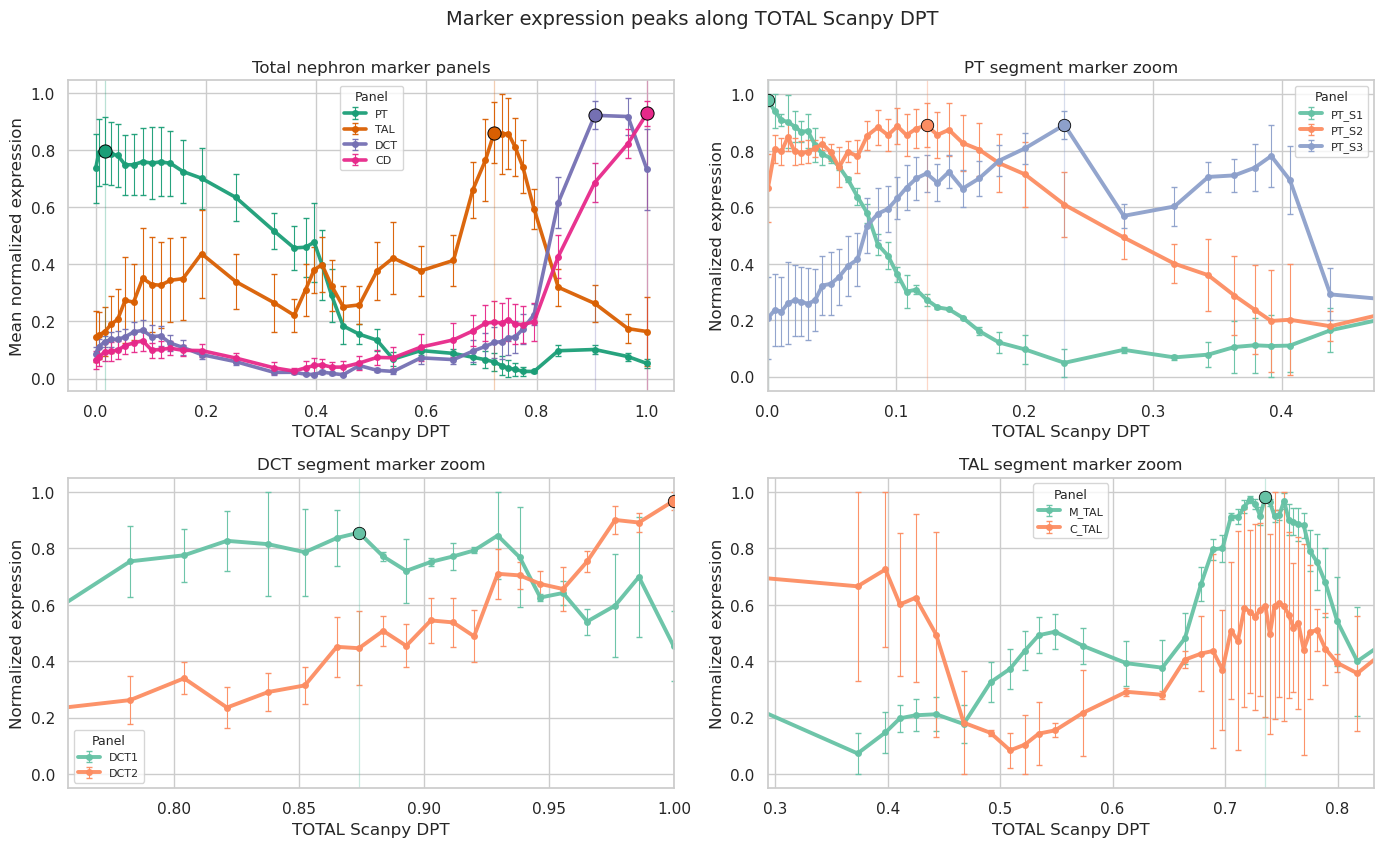

In [5]:
# Plot broad nephron and segment marker genes as one four-panel figure for a TOTAL pseudospace method.
def _expr_vector(adata, gene):
    expr_col = adata.X[:, adata.var_names.get_loc(gene)]
    return expr_col.toarray().ravel() if sparse.issparse(expr_col) else np.asarray(expr_col).ravel()


def _build_marker_trends_for_method(total_adata, pseudotime_col, marker_panels, n_bins=40, cell_mask=None):
    pt = total_adata.obs[pseudotime_col].to_numpy(dtype=float)
    valid_pt = np.isfinite(pt)
    if cell_mask is not None:
        valid_pt &= np.asarray(cell_mask, dtype=bool)
    if valid_pt.sum() < 30:
        raise ValueError(f'Too few finite {pseudotime_col} values to plot marker trends')

    bins = pd.qcut(pd.Series(pt[valid_pt]), q=n_bins, labels=False, duplicates='drop')
    valid_indices = np.where(valid_pt)[0]

    marker_rows = []
    for marker_panel, requested_genes in marker_panels.items():
        for requested_gene in requested_genes:
            gene = gene_lookup.get(requested_gene.upper())
            marker_rows.append({
                'marker_panel': marker_panel,
                'requested_gene': requested_gene,
                'gene': gene,
                'present': gene in total_adata.var_names if gene is not None else False,
            })
    marker_status = pd.DataFrame(marker_rows)
    present_marker_status = marker_status.loc[marker_status['present']].drop_duplicates(['marker_panel', 'gene']).copy()
    if present_marker_status.empty:
        raise ValueError('None of the selected marker genes are present after filtering')

    trend_rows = []
    for row in present_marker_status.to_dict('records'):
        gene = row['gene']
        expr = _expr_vector(total_adata, gene)
        tmp = pd.DataFrame({
            'bin': bins.to_numpy(),
            'pseudotime': pt[valid_indices],
            'expression': expr[valid_indices],
        })
        means = tmp.groupby('bin', observed=True).agg(
            pseudotime=('pseudotime', 'mean'),
            mean_expression=('expression', 'mean'),
        ).reset_index(drop=True)
        for mean_row in means.to_dict('records'):
            trend_rows.append({
                'marker_panel': row['marker_panel'],
                'gene': gene,
                'pseudotime': mean_row['pseudotime'],
                'mean_expression': mean_row['mean_expression'],
            })

    trend_df = pd.DataFrame(trend_rows)
    trend_df['normalized_expression'] = trend_df.groupby(['marker_panel', 'gene'], observed=True)['mean_expression'].transform(
        lambda x: (x - x.min()) / max(x.max() - x.min(), 1e-8)
    )
    peak_idx = trend_df.groupby(['marker_panel', 'gene'], observed=True)['normalized_expression'].idxmax()
    peak_df = trend_df.loc[peak_idx, ['marker_panel', 'gene', 'pseudotime', 'mean_expression', 'normalized_expression']].copy()
    peak_df = peak_df.rename(columns={'pseudotime': 'peak_pseudotime', 'mean_expression': 'peak_mean_expression'})
    peak_df = peak_df.sort_values(['marker_panel', 'peak_pseudotime', 'gene']).reset_index(drop=True)
    aggregate_df = trend_df.groupby(['marker_panel', 'pseudotime'], observed=True, as_index=False).agg(
        normalized_expression=('normalized_expression', 'mean'),
        expression_sem=('normalized_expression', lambda x: x.sem() if len(x) > 1 else 0.0),
    )
    aggregate_peak_idx = aggregate_df.groupby('marker_panel', observed=True)['normalized_expression'].idxmax()
    aggregate_peak_df = aggregate_df.loc[aggregate_peak_idx].rename(columns={'pseudotime': 'panel_peak_pseudotime'})
    return marker_status, trend_df, peak_df, aggregate_df, aggregate_peak_df


def plot_total_marker_trend_figure(total_adata, pseudotime_col, method_label, output_name):
    broad_marker_panels = {
        'PT': BROAD_SEGMENT_MARKERS['PT'],
        'TAL': BROAD_SEGMENT_MARKERS['TAL'],
        'DCT': BROAD_SEGMENT_MARKERS['DCT'],
        'CD': BROAD_SEGMENT_MARKERS['CNT_CD'],
    }
    zoom_marker_panels = {
        'PT': CONTINUUM_CONFIGS['PT']['segment_markers'],
        'DCT': CONTINUUM_CONFIGS['DCT']['segment_markers'],
        'TAL': CONTINUUM_CONFIGS['TAL']['segment_markers'],
    }

    broad_status, _, broad_peak_df, broad_aggregate_df, broad_aggregate_peak_df = _build_marker_trends_for_method(
        total_adata, pseudotime_col, broad_marker_panels
    )
    zoom_results = {
        region: _build_marker_trends_for_method(
            total_adata,
            pseudotime_col,
            panels,
            cell_mask=total_adata.obs['total_segment_marker_call'].eq(region).to_numpy(),
        )
        for region, panels in zoom_marker_panels.items()
    }

    display(broad_status.assign(view='broad_nephron', method=method_label))
    for nephron_region, (status, _, peak_df, _, _) in zoom_results.items():
        display(status.assign(view=f'{nephron_region}_zoom', method=method_label))
        display(peak_df.assign(view=f'{nephron_region}_zoom', method=method_label).sort_values(['marker_panel', 'peak_pseudotime', 'gene']))

    fig, axes = plt.subplots(2, 2, figsize=(14, 8.5), sharey=False)
    ax_broad, ax_pt, ax_dct, ax_tal = axes.ravel()

    broad_order = list(broad_marker_panels)
    broad_palette = dict(zip(broad_order, sns.color_palette('Dark2', n_colors=len(broad_order))))
    zoom_palettes = {
        region: dict(zip(zoom_marker_panels[region], sns.color_palette('Set2', n_colors=len(zoom_marker_panels[region]))))
        for region in zoom_marker_panels
    }

    for marker_panel in broad_order:
        panel_df = broad_aggregate_df.loc[broad_aggregate_df['marker_panel'] == marker_panel].sort_values('pseudotime')
        ax_broad.errorbar(
            panel_df['pseudotime'], panel_df['normalized_expression'], yerr=panel_df['expression_sem'],
            color=broad_palette[marker_panel], linewidth=2.6, marker='o', markersize=4,
            capsize=2, elinewidth=0.8, alpha=0.95, label=marker_panel,
        )
    for _, row in broad_aggregate_peak_df.iterrows():
        ax_broad.scatter(row['panel_peak_pseudotime'], row['normalized_expression'], color=broad_palette[row['marker_panel']], edgecolor='black', linewidth=0.7, s=90, zorder=5)
        ax_broad.axvline(row['panel_peak_pseudotime'], color=broad_palette[row['marker_panel']], linewidth=0.9, alpha=0.3)
    ax_broad.set_title('Total nephron marker panels')
    ax_broad.set_xlabel(method_label)
    ax_broad.set_ylabel('Mean normalized expression')
    ax_broad.legend(title='Panel', fontsize=8, title_fontsize=9)

    for nephron_region, ax in [('PT', ax_pt), ('DCT', ax_dct), ('TAL', ax_tal)]:
        _, _, peak_df, aggregate_df, aggregate_peak_df = zoom_results[nephron_region]
        panel_order = list(zoom_marker_panels[nephron_region])
        palette = zoom_palettes[nephron_region]
        for marker_panel in panel_order:
            panel_df = aggregate_df.loc[aggregate_df['marker_panel'] == marker_panel].sort_values('pseudotime')
            ax.errorbar(
                panel_df['pseudotime'], panel_df['normalized_expression'], yerr=panel_df['expression_sem'],
                color=palette[marker_panel], linewidth=2.8, marker='o', markersize=4,
                capsize=2, elinewidth=0.8, alpha=0.95, label=marker_panel,
            )
        for _, row in aggregate_peak_df.iterrows():
            ax.scatter(row['panel_peak_pseudotime'], row['normalized_expression'], color=palette[row['marker_panel']], edgecolor='black', linewidth=0.6, s=80, zorder=5)
            ax.axvline(row['panel_peak_pseudotime'], color=palette[row['marker_panel']], linewidth=0.9, alpha=0.35)
        peak_min = peak_df['peak_pseudotime'].min()
        peak_max = peak_df['peak_pseudotime'].max()
        pad = max(0.08, 0.18 * max(peak_max - peak_min, 1e-8))
        x_min = max(0, peak_min - pad)
        x_max = min(1, peak_max + pad)
        if x_max - x_min < 0.2:
            center = 0.5 * (x_min + x_max)
            x_min = max(0, center - 0.1)
            x_max = min(1, center + 0.1)
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(-0.05, 1.05)
        ax.set_title(f'{nephron_region} segment marker zoom')
        ax.set_xlabel(method_label)
        ax.set_ylabel('Normalized expression')
        ax.legend(title='Panel', fontsize=8, title_fontsize=9)

    fig.suptitle(f'Marker expression peaks along {method_label}', y=0.995, fontsize=14)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / output_name, dpi=200, bbox_inches='tight')
    plt.show()
    return {
        'broad': (broad_status, broad_peak_df, broad_aggregate_df),
        'zoom': zoom_results,
    }


dpt_marker_trends = plot_total_marker_trend_figure(
    dpt_loaded['TOTAL']['adata'],
    'total_scanpy_dpt',
    'TOTAL Scanpy DPT',
    'total_scanpy_dpt_marker_trends.png',
)


## Method 2: Slingshot


In [6]:
# ---------------------------------------------------------------------
# One-time R/Bioconductor setup for Slingshot through rpy2
# Installs packages into a persistent local folder: ./r_libs
# ---------------------------------------------------------------------
from pathlib import Path
import os
import rpy2.robjects as ro
from rpy2.robjects.packages import importr, isinstalled

# Try to use PROJECT_DIR if your notebook already has it; otherwise use current directory.
try:
    project_dir = Path(PROJECT_DIR).resolve()
except NameError:
    project_dir = Path.cwd().resolve()

# Persistent local R package directory.
R_LIB_DIR = project_dir / "r_libs"
R_LIB_DIR.mkdir(parents=True, exist_ok=True)

local_r_lib = str(R_LIB_DIR)

# Make R use this library path first.
ro.r.assign("local_r_lib", local_r_lib)
ro.r("""
dir.create(local_r_lib, recursive = TRUE, showWarnings = FALSE)
.libPaths(c(local_r_lib, .libPaths()))
message("Using R library paths:")
print(.libPaths())
""")

utils = importr("utils")

# Install BiocManager if missing.
if not isinstalled("BiocManager", lib_loc=local_r_lib):
    print(f"Installing BiocManager into {local_r_lib}")
    utils.install_packages(
        ro.StrVector(["BiocManager"]),
        repos="https://cloud.r-project.org",
        lib=local_r_lib
    )

biocmanager = importr("BiocManager", lib_loc=local_r_lib)

# CRAN packages needed by Slingshot dependencies.
cran_pkgs = [
    "Matrix",
    "Rcpp",
    "RcppArmadillo",
    "matrixStats",
    "igraph",
    "princurve",
]

# Bioconductor packages needed for the SingleCellExperiment + Slingshot runtime dependency chain.
bioc_pkgs = [
    "BiocGenerics",
    "S4Vectors",
    "IRanges",
    "GenomeInfoDb",
    "XVector",
    "GenomicRanges",
    "MatrixGenerics",
    "S4Arrays",
    "SparseArray",
    "DelayedArray",
    "DelayedMatrixStats",
    "Biobase",
    "SummarizedExperiment",
    "SingleCellExperiment",
    "TrajectoryUtils",
    "slingshot",
]

# Install missing CRAN packages.
missing_cran = [pkg for pkg in cran_pkgs if not isinstalled(pkg, lib_loc=local_r_lib)]
if missing_cran:
    print(f"Installing missing CRAN packages: {missing_cran}")
    utils.install_packages(
        ro.StrVector(missing_cran),
        repos="https://cloud.r-project.org",
        lib=local_r_lib
    )

# Install missing Bioconductor packages.
missing_bioc = [pkg for pkg in bioc_pkgs if not isinstalled(pkg, lib_loc=local_r_lib)]
if missing_bioc:
    print(f"Installing missing Bioconductor packages: {missing_bioc}")
    ro.r("options(repos = BiocManager::repositories())")
    biocmanager.install(
        ro.StrVector(missing_bioc),
        ask=False,
        update=False,
        dependencies=ro.StrVector(["Depends", "Imports", "LinkingTo"]),
        lib=local_r_lib
    )

# Verify core packages and known runtime dependencies load.
required_pkgs = [
    "Matrix",
    "matrixStats",
    "princurve",
    "BiocGenerics",
    "S4Vectors",
    "IRanges",
    "GenomeInfoDb",
    "GenomicRanges",
    "MatrixGenerics",
    "S4Arrays",
    "SparseArray",
    "DelayedArray",
    "DelayedMatrixStats",
    "Biobase",
    "SummarizedExperiment",
    "SingleCellExperiment",
    "TrajectoryUtils",
    "slingshot",
]
for pkg in required_pkgs:
    print(f"Checking R package: {pkg}")
    importr(pkg, lib_loc=local_r_lib, on_conflict="warn")

print("✅ Slingshot R environment is installed and ready.")
print(f"Persistent R library directory: {local_r_lib}")

R callback write-console: Using R library paths:
  


[1] "/home/edmund/Desktop/pseudospace_reconstruction/r_libs" 
[2] "/home/edmund/Desktop/pseudospace_reconstruction/.r_libs"
[3] "/usr/local/lib/R/site-library"                          
[4] "/usr/lib/R/site-library"                                
[5] "/usr/lib/R/library"                                     
Checking R package: Matrix
Checking R package: matrixStats
Checking R package: princurve
Checking R package: BiocGenerics


/home/edmund/ENTER/envs/tubule_pseudospace_reconstruction/lib/python3.10/site-packages/rpy2/robjects/packages_utils.py:127: UserWarning: Conflict when converting R symbols in the package "princurve" to Python symbols: 
-lines_principal_curve -> lines.principal_curve, lines.principal.curve
- plot_principal_curve -> plot.principal_curve, plot.principal.curve
- points_principal_curve -> points.principal_curve, points.principal.curve
  warn(msg)


Checking R package: S4Vectors
Checking R package: IRanges
Checking R package: GenomeInfoDb
Checking R package: GenomicRanges
Checking R package: MatrixGenerics
Checking R package: S4Arrays
Checking R package: SparseArray
Checking R package: DelayedArray
Checking R package: DelayedMatrixStats
Checking R package: Biobase
Checking R package: SummarizedExperiment
Checking R package: SingleCellExperiment
Checking R package: TrajectoryUtils
Checking R package: slingshot
✅ Slingshot R environment is installed and ready.
Persistent R library directory: /home/edmund/Desktop/pseudospace_reconstruction/r_libs


In [7]:
slingshot_loaded = clone_preprocessed_continua()

# Prepare the optional R bridge and Slingshot dependencies.
r_ready = False
slingshot_available = False
try:
    import rpy2.robjects as ro
    from rpy2.robjects import numpy2ri, pandas2ri
    from rpy2.robjects.conversion import localconverter
    from rpy2.robjects.packages import importr, isinstalled

    local_r_lib = str(R_LIB_DIR)
    ro.r.assign('local_r_lib', local_r_lib)
    ro.r('dir.create(local_r_lib, recursive=TRUE, showWarnings=FALSE)')
    ro.r('.libPaths(c(local_r_lib, .libPaths()))')

    # Install BiocManager locally when needed so Bioconductor packages can be resolved.
    if not isinstalled('BiocManager', lib_loc=local_r_lib):
        print(f'Installing BiocManager into {local_r_lib}')
        utils = importr('utils')
        utils.install_packages(ro.StrVector(['BiocManager']), repos='https://cloud.r-project.org', lib=local_r_lib)

    # Install missing Slingshot dependencies into the project-local R library.
    if isinstalled('BiocManager', lib_loc=local_r_lib):
        missing = [pkg for pkg in ['S4Vectors', 'SingleCellExperiment', 'slingshot'] if not isinstalled(pkg, lib_loc=local_r_lib)]
        if missing:
            print(f'Attempting Bioconductor installation into {local_r_lib}: {missing}')
            ro.r('options(repos = c(CRAN = "https://cloud.r-project.org"))')
            try:
                importr('BiocManager', lib_loc=local_r_lib).install(ro.StrVector(missing), ask=False, update=False, lib=local_r_lib)
            except Exception as exc:
                print(f'Optional Slingshot package install did not fully succeed: {exc}')

    importr('Matrix')
    importr('S4Vectors')
    importr('SingleCellExperiment')
    importr('slingshot')
    r_ready = True
    slingshot_available = True
except Exception as exc:
    print(f'Slingshot unavailable: {exc}')

# Run Slingshot once on the total nephron continuum.
for continuum, obj in {'TOTAL': slingshot_loaded['TOTAL']}.items():
    print('\n' + '=' * 80)
    print(f'Running Slingshot for {continuum}')
    adata = obj['adata']
    config = obj['config']
    prefix = config['prefix']
    marker_axis = adata.obs[f'{prefix}_marker_axis'].to_numpy(dtype=float)

    if not (r_ready and slingshot_available):
        print('Skipped Slingshot because required R packages are unavailable')
        continue

    # Slingshot receives an unsupervised Leiden clustering, not marker-derived labels.
    rep = next((key for key in [f'X_pca_harmony_{prefix}', 'X_pca_harmony', 'X_harmony', 'X_pca', f'X_umap_harmony_{prefix}', 'X_umap'] if key in adata.obsm), None)
    if rep is None:
        sc.pp.pca(adata, n_comps=min(N_PCS_FALLBACK, adata.n_vars - 1), random_state=RANDOM_STATE)
        rep = 'X_pca'
    print(f'{prefix}: Slingshot/Leiden uses representation {rep}')

    neighbors_key = f'{prefix}_slingshot_neighbors'
    leiden_col = f'{prefix}_slingshot_leiden'
    sc.pp.neighbors(adata, n_neighbors=N_NEIGHBORS, use_rep=rep, key_added=neighbors_key, random_state=RANDOM_STATE)
    sc.tl.leiden(adata, resolution=1.0, neighbors_key=neighbors_key, key_added=leiden_col, random_state=RANDOM_STATE)

    # Pick the starting cluster only after unsupervised clustering, using the marker-axis score.
    cluster_marker_means = adata.obs.assign(_marker_axis=marker_axis).groupby(leiden_col, observed=True)['_marker_axis'].mean()
    start_cluster = str(cluster_marker_means.idxmin())
    print(f'{prefix}: Leiden clusters={adata.obs[leiden_col].nunique()}, start cluster={start_cluster}')
    display(cluster_marker_means.sort_values().to_frame('mean_marker_axis'))

    # Run Slingshot on every tubule in the total nephron continuum.
    sample_idx = np.arange(adata.n_obs)

    sampled = adata[sample_idx].copy()
    embedding = np.asarray(sampled.obsm[rep], dtype=float)
    if embedding.shape[1] > 10:
        embedding = embedding[:, :10]
    clusters = sampled.obs[leiden_col].astype(str).to_numpy()
    if start_cluster not in set(clusters):
        sampled_cluster_means = sampled.obs.assign(_marker_axis=marker_axis[sample_idx]).groupby(leiden_col, observed=True)['_marker_axis'].mean()
        start_cluster = str(sampled_cluster_means.idxmin())
        print(f'{prefix}: start cluster was not sampled; using sampled start cluster={start_cluster}')

    # Build a minimal SingleCellExperiment in R and run Slingshot on embedding + Leiden labels + start cluster.
    try:
        with localconverter(ro.default_converter + numpy2ri.converter + pandas2ri.converter):
            r_emb = ro.r.matrix(embedding, nrow=embedding.shape[0], ncol=embedding.shape[1])
            r_clusters = ro.StrVector(clusters)
            ro.r.assign('emb_tmp', r_emb)
            ro.r.assign('clusters_tmp', r_clusters)
            ro.r.assign('start_cluster_tmp', start_cluster)
            ro.r('counts_tmp <- Matrix::Matrix(0, nrow=1, ncol=nrow(emb_tmp), sparse=TRUE)')
            ro.r('rownames(counts_tmp) <- "dummy"')
            ro.r('colnames(counts_tmp) <- paste0("cell_", seq_len(ncol(counts_tmp)))')
            ro.r('sce_tmp <- SingleCellExperiment::SingleCellExperiment(assays=list(counts=counts_tmp))')
            ro.r('reducedDims(sce_tmp) <- S4Vectors::SimpleList(TRAJ=emb_tmp)')
            ro.r('colLabels(sce_tmp) <- clusters_tmp')
            ro.r('sce_tmp <- slingshot::slingshot(sce_tmp, clusterLabels=colLabels(sce_tmp), reducedDim="TRAJ", start.clus=start_cluster_tmp)')
            pt = np.asarray(ro.r('slingPseudotime(sce_tmp, na=FALSE)[, 1]'), dtype=float)
    except Exception as exc:
        print(f'Slingshot failed for {continuum}: {exc}')
        continue

    # Orient and normalize Slingshot pseudotime before inserting it back into the full object.
    valid = np.isfinite(pt) & np.isfinite(marker_axis[sample_idx])
    oriented = pt.copy()
    if valid.sum() >= 10:
        corr = spearmanr(oriented[valid], marker_axis[sample_idx][valid]).correlation
        if np.isfinite(corr) and corr < 0:
            oriented = -oriented
    finite = np.isfinite(oriented)
    normalized_sample = np.full(oriented.shape, np.nan, dtype=float)
    if finite.sum() > 0:
        p5, p95 = np.nanpercentile(oriented[finite], [5, 95])
        normalized_sample[finite] = np.clip((oriented[finite] - p5) / max(p95 - p5, 1e-8), 0, 1)

    # Insert Slingshot pseudotime back into the full object.
    full = np.full(adata.n_obs, np.nan, dtype=float)
    full[sample_idx] = normalized_sample
    col = f'{prefix}_slingshot'
    adata.obs[col] = full
    obj['method_cols'].append(col)
    obj['method_notes'][col] = f'Slingshot ran on {len(sample_idx):,}/{adata.n_obs:,} cells using {rep}, Leiden labels, start cluster {start_cluster}'


R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :  
R callback write-console: 
   
R callback write-console:  libraries ‘/usr/local/lib/R/site-library’, ‘/usr/lib/R/site-library’ contain no packages
  



Running Slingshot for TOTAL
total: Slingshot/Leiden uses representation X_harmony
computing neighbors
    finished (0:00:06)
running Leiden clustering
    finished (0:00:43)
total: Leiden clusters=12, start cluster=4


,mean_marker_axis
total_slingshot_leiden,
4,-1.679412
3,-1.500352
0,-0.927940
2,-0.185822
6,-0.052155
9,0.071766
11,0.282926
5,0.290755
8,0.491736


R callback write-console: In addition:   
R callback write-console: Warning messages:
  
R callback write-console: 1:   
R callback write-console: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :  
R callback write-console: 
   
R callback write-console:  libraries ‘/usr/local/lib/R/site-library’, ‘/usr/lib/R/site-library’ contain no packages
  
R callback write-console: 2:   
R callback write-console: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :  
R callback write-console: 
   
R callback write-console:  libraries ‘/usr/local/lib/R/site-library’, ‘/usr/lib/R/site-library’ contain no packages
  
R callback write-console: 3:   
R callback write-console: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :  
R callback write-console: 
   
R callback write-console:  libraries ‘/usr/local/lib/R/site-library’, ‘/usr/lib/R/site-library’ contain no packages
  
R callback write-console: 4:   
R call

,marker_panel,requested_gene,gene,present,view,method
0,PT,Slc34a1,Slc34a1,True,broad_nephron,TOTAL Slingshot
1,PT,Lrp2,Lrp2,True,broad_nephron,TOTAL Slingshot
2,PT,Slc5a12,Slc5a12,True,broad_nephron,TOTAL Slingshot
3,PT,Slc13a3,Slc13a3,True,broad_nephron,TOTAL Slingshot
4,PT,Slc22a6,Slc22a6,True,broad_nephron,TOTAL Slingshot
5,PT,Slc22a7,Slc22a7,True,broad_nephron,TOTAL Slingshot
6,PT,Aqp1,Aqp1,True,broad_nephron,TOTAL Slingshot
7,TAL,Umod,Umod,True,broad_nephron,TOTAL Slingshot
8,TAL,Slc12a1,Slc12a1,True,broad_nephron,TOTAL Slingshot
9,TAL,Cldn10,Cldn10,True,broad_nephron,TOTAL Slingshot


,marker_panel,requested_gene,gene,present,view,method
0,PT_S1,Slc5a2,Slc5a2,True,PT_zoom,TOTAL Slingshot
1,PT_S1,Slc5a12,Slc5a12,True,PT_zoom,TOTAL Slingshot
2,PT_S2,Slc22a8,Slc22a8,True,PT_zoom,TOTAL Slingshot
3,PT_S2,Slc22a6,Slc22a6,True,PT_zoom,TOTAL Slingshot
4,PT_S2,Slc13a3,Slc13a3,True,PT_zoom,TOTAL Slingshot
5,PT_S2,Slc22a2,Slc22a2,True,PT_zoom,TOTAL Slingshot
6,PT_S2,Slc34a1,Slc34a1,True,PT_zoom,TOTAL Slingshot
7,PT_S3,Slc7a13,Slc7a13,True,PT_zoom,TOTAL Slingshot
8,PT_S3,Slc5a8,Slc5a8,True,PT_zoom,TOTAL Slingshot
9,PT_S3,Slc38a3,Slc38a3,True,PT_zoom,TOTAL Slingshot


,marker_panel,gene,peak_pseudotime,peak_mean_expression,normalized_expression,view,method
0,PT_S1,Slc5a2,0.000053,2.181627,1.0,PT_zoom,TOTAL Slingshot
1,PT_S1,Slc5a12,0.038576,2.288021,1.0,PT_zoom,TOTAL Slingshot
2,PT_S2,Slc34a1,0.000053,3.302117,1.0,PT_zoom,TOTAL Slingshot
3,PT_S2,Slc22a8,0.084994,2.165233,1.0,PT_zoom,TOTAL Slingshot
4,PT_S2,Slc13a3,0.117897,2.097310,1.0,PT_zoom,TOTAL Slingshot
5,PT_S2,Slc22a6,0.153670,2.305984,1.0,PT_zoom,TOTAL Slingshot
6,PT_S2,Slc22a2,0.170841,1.542541,1.0,PT_zoom,TOTAL Slingshot
7,PT_S3,Pck1,0.139166,3.716002,1.0,PT_zoom,TOTAL Slingshot
8,PT_S3,Hao2,0.191768,1.488610,1.0,PT_zoom,TOTAL Slingshot
9,PT_S3,Slc38a3,0.256529,0.609581,1.0,PT_zoom,TOTAL Slingshot


,marker_panel,requested_gene,gene,present,view,method
0,DCT1,Slc12a3,Slc12a3,True,DCT_zoom,TOTAL Slingshot
1,DCT1,Pvalb,Pvalb,True,DCT_zoom,TOTAL Slingshot
2,DCT2,Hsd11b2,Hsd11b2,True,DCT_zoom,TOTAL Slingshot
3,DCT2,Scnn1g,Scnn1g,True,DCT_zoom,TOTAL Slingshot
4,DCT2,Calb1,Calb1,True,DCT_zoom,TOTAL Slingshot


,marker_panel,gene,peak_pseudotime,peak_mean_expression,normalized_expression,view,method
0,DCT1,Slc12a3,0.844964,4.580501,1.0,DCT_zoom,TOTAL Slingshot
1,DCT1,Pvalb,0.853459,1.178183,1.0,DCT_zoom,TOTAL Slingshot
2,DCT2,Calb1,0.933799,3.601945,1.0,DCT_zoom,TOTAL Slingshot
3,DCT2,Hsd11b2,0.990875,3.857394,1.0,DCT_zoom,TOTAL Slingshot
4,DCT2,Scnn1g,0.999832,1.702103,1.0,DCT_zoom,TOTAL Slingshot


,marker_panel,requested_gene,gene,present,view,method
0,M_TAL,Umod,Umod,True,TAL_zoom,TOTAL Slingshot
1,M_TAL,Slc12a1,Slc12a1,True,TAL_zoom,TOTAL Slingshot
2,M_TAL,Kcnj1,Kcnj1,True,TAL_zoom,TOTAL Slingshot
3,M_TAL,Egf,Egf,True,TAL_zoom,TOTAL Slingshot
4,C_TAL,Cldn10,Cldn10,True,TAL_zoom,TOTAL Slingshot
5,C_TAL,Bcl6,Bcl6,True,TAL_zoom,TOTAL Slingshot
6,C_TAL,Nos1,None,False,TAL_zoom,TOTAL Slingshot


,marker_panel,gene,peak_pseudotime,peak_mean_expression,normalized_expression,view,method
0,C_TAL,Bcl6,0.277260,0.626729,1.0,TAL_zoom,TOTAL Slingshot
1,C_TAL,Cldn10,0.656226,1.527948,1.0,TAL_zoom,TOTAL Slingshot
2,M_TAL,Slc12a1,0.636542,3.181571,1.0,TAL_zoom,TOTAL Slingshot
3,M_TAL,Umod,0.640508,5.542400,1.0,TAL_zoom,TOTAL Slingshot
4,M_TAL,Kcnj1,0.656226,1.765201,1.0,TAL_zoom,TOTAL Slingshot
5,M_TAL,Egf,0.942684,2.988927,1.0,TAL_zoom,TOTAL Slingshot


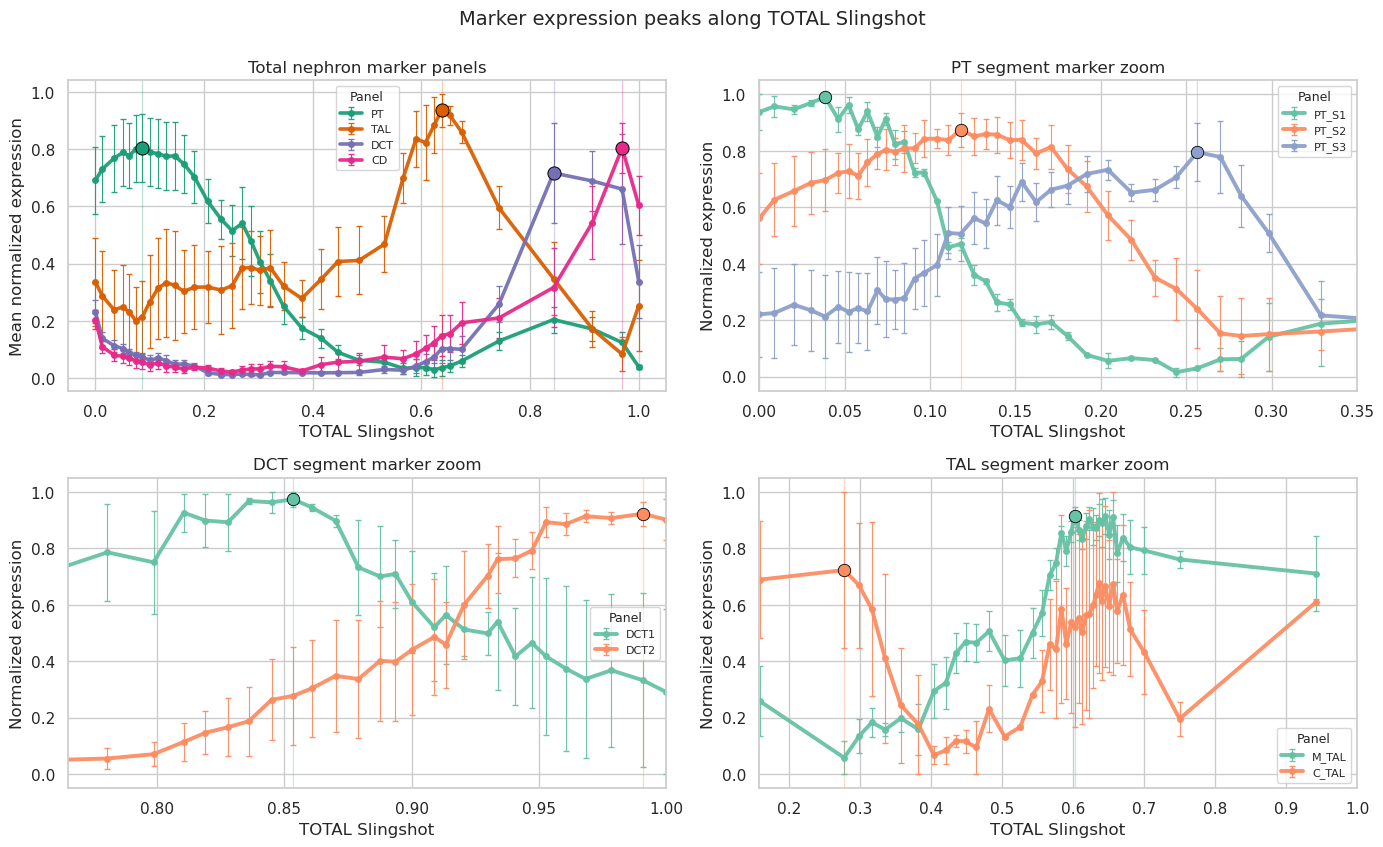

In [8]:
# Plot Slingshot marker trends using the same four-panel layout.
slingshot_marker_trends = plot_total_marker_trend_figure(
    slingshot_loaded['TOTAL']['adata'],
    'total_slingshot',
    'TOTAL Slingshot',
    'total_slingshot_marker_trends.png',
)


## Method 3: Monocle


In [9]:
# ---------------------------------------------------------------------
# One-time R/GitHub setup for Monocle3 through rpy2
# Monocle3 is installed from GitHub because it is not available from Bioconductor 3.20.
# Existing packages are reused; only missing packages are installed.
# ---------------------------------------------------------------------
from pathlib import Path
import os
import shutil
import subprocess
import sys
import rpy2.robjects as ro
from rpy2.robjects.packages import importr, isinstalled

try:
    project_dir = Path(PROJECT_DIR).resolve()
except NameError:
    project_dir = Path.cwd().resolve()

R_LIB_DIR = project_dir / "r_libs"
R_LIB_DIR.mkdir(parents=True, exist_ok=True)
local_r_lib = str(R_LIB_DIR)

# nloptr/lme4 and s2/sf compile from source on Linux; make cmake available from this Python env if needed.
if shutil.which("cmake") is None:
    print("cmake was not found on PATH; installing Python cmake wheel for R package compilation")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "cmake"])
python_bin = str(Path(sys.executable).resolve().parent)
os.environ["PATH"] = python_bin + os.pathsep + os.environ.get("PATH", "")
os.environ["USE_BUNDLED_LIBUV"] = "1"

ro.r.assign("local_r_lib", local_r_lib)
ro.r.assign("python_bin", python_bin)
ro.r("""
dir.create(local_r_lib, recursive = TRUE, showWarnings = FALSE)
.libPaths(c(local_r_lib, .libPaths()))
Sys.setenv(PATH = paste(python_bin, Sys.getenv("PATH"), sep = .Platform$path.sep))
Sys.setenv(USE_BUNDLED_LIBUV = "1")
message("Using R library paths:")
print(.libPaths())
message("Using cmake: ", Sys.which("cmake"))
""")

utils = importr("utils")

if not isinstalled("BiocManager", lib_loc=local_r_lib):
    print(f"Installing BiocManager into {local_r_lib}")
    utils.install_packages(
        ro.StrVector(["BiocManager"]),
        repos="https://cloud.r-project.org",
        lib=local_r_lib,
    )

if not isinstalled("remotes", lib_loc=local_r_lib):
    print(f"Installing remotes into {local_r_lib}")
    utils.install_packages(
        ro.StrVector(["remotes"]),
        repos="https://cloud.r-project.org",
        lib=local_r_lib,
    )

biocmanager = importr("BiocManager", lib_loc=local_r_lib)
remotes = importr("remotes", lib_loc=local_r_lib)

# CRAN dependencies that Monocle3 requires directly or through lme4/plotly/sf/shiny/spdep.
# Install in stages so downstream packages retry after low-level compiled deps succeed.
monocle_cran_groups = [
    ["fs", "sass"],
    ["bslib"],
    ["rmarkdown", "shiny"],
    ["htmlwidgets"],
    ["plotly"],
    ["nloptr", "lme4"],
    ["s2", "sf", "spdep"],
]
monocle_cran_pkgs = [pkg for group in monocle_cran_groups for pkg in group]
for cran_group in monocle_cran_groups:
    missing_group = [pkg for pkg in cran_group if not isinstalled(pkg, lib_loc=local_r_lib)]
    if missing_group:
        print(f"Installing missing Monocle3 CRAN dependencies: {missing_group}")
        utils.install_packages(
            ro.StrVector(missing_group),
            repos="https://cloud.r-project.org",
            lib=local_r_lib,
            dependencies=ro.StrVector(["Depends", "Imports", "LinkingTo"]),
        )
        still_missing_group = [pkg for pkg in missing_group if not isinstalled(pkg, lib_loc=local_r_lib)]
        if still_missing_group:
            raise RuntimeError(
                "These Monocle3 CRAN dependencies failed to install: "
                + ", ".join(still_missing_group)
                + ". Check the R install output immediately above for the first package error."
            )

# Required by current Monocle3 GitHub install instructions and runtime imports.
monocle_bioc_pkgs = [
    "BiocGenerics",
    "DelayedArray",
    "DelayedMatrixStats",
    "limma",
    "S4Vectors",
    "SingleCellExperiment",
    "SummarizedExperiment",
    "batchelor",
    "HDF5Array",
    "ggrastr",
]
missing_bioc = [pkg for pkg in monocle_bioc_pkgs if not isinstalled(pkg, lib_loc=local_r_lib)]
if missing_bioc:
    print(f"Installing missing Monocle3 Bioconductor dependencies: {missing_bioc}")
    ro.r("options(repos = BiocManager::repositories())")
    biocmanager.install(
        ro.StrVector(missing_bioc),
        ask=False,
        update=False,
        dependencies=ro.StrVector(["Depends", "Imports", "LinkingTo"]),
        lib=local_r_lib,
    )

# BPCells is required by the current Monocle3 GitHub package.
if not isinstalled("BPCells", lib_loc=local_r_lib):
    print(f"Installing BPCells from GitHub into {local_r_lib}")
    remotes.install_github(
        "bnprks/BPCells/r",
        lib=local_r_lib,
        upgrade="never",
        dependencies=ro.StrVector(["Depends", "Imports", "LinkingTo"]),
    )

required_before_monocle = monocle_cran_pkgs + monocle_bioc_pkgs + ["BPCells"]
still_missing = [pkg for pkg in required_before_monocle if not isinstalled(pkg, lib_loc=local_r_lib)]
if still_missing:
    raise RuntimeError(
        "These Monocle3 dependencies are still missing after installation: "
        + ", ".join(still_missing)
        + ". Check the R install output above for the first package that failed."
    )

if not isinstalled("monocle3", lib_loc=local_r_lib):
    print(f"Installing monocle3 from GitHub into {local_r_lib}")
    remotes.install_github(
        "cole-trapnell-lab/monocle3",
        lib=local_r_lib,
        upgrade="never",
        dependencies=ro.StrVector(["Depends", "Imports", "LinkingTo"]),
    )

print("Checking R package: monocle3")
importr("monocle3", lib_loc=local_r_lib, on_conflict="warn")
print("✅ Monocle3 R environment is installed and ready.")
print(f"Persistent R library directory: {local_r_lib}")


R callback write-console: Using R library paths:
  


[1] "/home/edmund/Desktop/pseudospace_reconstruction/r_libs" 
[2] "/home/edmund/Desktop/pseudospace_reconstruction/.r_libs"
[3] "/usr/local/lib/R/site-library"                          
[4] "/usr/lib/R/site-library"                                
[5] "/usr/lib/R/library"                                     


R callback write-console: Using cmake: /home/edmund/ENTER/envs/tubule_pseudospace_reconstruction/bin/cmake
  


Checking R package: monocle3
✅ Monocle3 R environment is installed and ready.
Persistent R library directory: /home/edmund/Desktop/pseudospace_reconstruction/r_libs


In [10]:
monocle_loaded = clone_preprocessed_continua()
for obj in monocle_loaded.values():
    obj['gene_lookup'] = gene_lookup

# Prepare an independent R bridge and Monocle3 dependencies.
r_ready = False
try:
    import rpy2.robjects as ro
    from rpy2.robjects import numpy2ri, pandas2ri
    from rpy2.robjects.conversion import localconverter
    from rpy2.robjects.packages import importr, isinstalled

    local_r_lib = str(R_LIB_DIR)
    ro.r.assign('local_r_lib', local_r_lib)
    ro.r('dir.create(local_r_lib, recursive=TRUE, showWarnings=FALSE)')
    ro.r('.libPaths(c(local_r_lib, .libPaths()))')
    if not isinstalled('BiocManager', lib_loc=local_r_lib):
        print(f'Installing BiocManager into {local_r_lib}')
        utils = importr('utils')
        utils.install_packages(ro.StrVector(['BiocManager']), repos='https://cloud.r-project.org', lib=local_r_lib)
    r_ready = True
except Exception as exc:
    print(f'R bridge unavailable for Monocle3: {exc}')

monocle_available = False
if r_ready:
    try:
        importr('monocle3', lib_loc=str(R_LIB_DIR), on_conflict='warn')
        importr('SingleCellExperiment', lib_loc=str(R_LIB_DIR), on_conflict='warn')
        ro.r('suppressPackageStartupMessages(library(SingleCellExperiment))')
        monocle_available = True
    except Exception as exc:
        print(f'Monocle3 unavailable: {exc}')
        print('Run the Monocle3 setup cell immediately above this one, then rerun this cell.')
else:
    print('Monocle3 skipped because rpy2/R setup is unavailable')


def _run_monocle3_total(loaded, *, use_harmonized_umap=False):
    """Run Monocle3 on TOTAL, optionally learning the graph on the existing harmonized UMAP."""
    label = 'Monocle3 on harmonized UMAP' if use_harmonized_umap else 'Monocle3'

    for continuum, obj in {'TOTAL': loaded['TOTAL']}.items():
        print('\n' + '=' * 80)
        print(f'Running {label} for {continuum}')
        adata = obj['adata']
        config = obj['config']
        prefix = config['prefix']
        marker_axis = adata.obs[f'{prefix}_marker_axis'].to_numpy(dtype=float)

        if not monocle_available:
            print(f'Skipped {label} because required R packages are unavailable')
            continue

        # Run Monocle3 on every tubule in the total nephron continuum.
        sample_idx = np.arange(adata.n_obs)

        # Monocle3 expects counts and performs its own normalization/PCA. For the harmonized-UMAP
        # variant, that preprocessing is still used to construct the CDS, but graph learning uses
        # the existing harmonized UMAP coordinates instead of Monocle3's recomputed UMAP.
        sampled = adata[sample_idx].copy()
        count_matrix = sampled.layers['counts'] if 'counts' in sampled.layers else sampled.X
        count_matrix = sparse.csr_matrix(count_matrix)
        nonzero_expression_cells = np.asarray(count_matrix.sum(axis=1)).ravel() > 0
        if nonzero_expression_cells.sum() < 30:
            print(f'Skipped {label} because too few cells have nonzero counts in the filtered feature matrix')
            continue
        if nonzero_expression_cells.sum() < len(nonzero_expression_cells):
            print(f'{prefix}: dropping {len(nonzero_expression_cells) - int(nonzero_expression_cells.sum()):,} cells with zero filtered-feature counts before {label}')
        monocle_sample_idx = sample_idx[nonzero_expression_cells]
        sampled_for_monocle = sampled[nonzero_expression_cells].copy()
        counts_genes_by_cells = sparse.csc_matrix(count_matrix[nonzero_expression_cells].T)
        genes = sampled_for_monocle.var_names.astype(str).tolist()
        metadata_cols = [col for col in ['sample', 'condition', 'species', 'broad_tubule_marker_call'] if col in sampled_for_monocle.obs.columns]
        cell_metadata = sampled_for_monocle.obs[metadata_cols].copy()
        cell_metadata['cell_id'] = sampled_for_monocle.obs_names
        cell_metadata.index = sampled_for_monocle.obs_names
        gene_metadata = pd.DataFrame({'gene_short_name': genes}, index=genes)

        umap_key = None
        umap_df = None
        if use_harmonized_umap:
            preferred_umap_keys = [f'X_umap_harmony_{prefix}', 'X_umap_harmony', 'X_umap']
            umap_key = next((key for key in preferred_umap_keys if key in sampled_for_monocle.obsm), None)
            if umap_key is None:
                print(f'Skipped {label} because no harmonized UMAP was found in {preferred_umap_keys}')
                continue
            umap = np.asarray(sampled_for_monocle.obsm[umap_key])[:, :2]
            finite_umap = np.isfinite(umap).all(axis=1)
            if finite_umap.sum() < 30:
                print(f'Skipped {label} because {umap_key} has too few finite coordinates')
                continue
            if finite_umap.sum() < len(finite_umap):
                print(f'{prefix}: dropping {len(finite_umap) - int(finite_umap.sum()):,} cells with non-finite {umap_key} before {label}')
                monocle_sample_idx = monocle_sample_idx[finite_umap]
                sampled_for_monocle = sampled_for_monocle[finite_umap].copy()
                counts_genes_by_cells = sparse.csc_matrix(count_matrix[monocle_sample_idx].T)
                cell_metadata = cell_metadata.loc[sampled_for_monocle.obs_names].copy()
                umap = np.asarray(sampled_for_monocle.obsm[umap_key])[:, :2]
            umap_df = pd.DataFrame(umap, index=sampled_for_monocle.obs_names, columns=['UMAP_1', 'UMAP_2'])

        # Build a sparse genes-by-cells count matrix in R, then learn and root the Monocle3 graph.
        try:
            with localconverter(ro.default_converter + numpy2ri.converter + pandas2ri.converter):
                ro.r.assign('counts_i_tmp', ro.IntVector(counts_genes_by_cells.indices))
                ro.r.assign('counts_p_tmp', ro.IntVector(counts_genes_by_cells.indptr))
                ro.r.assign('counts_x_tmp', ro.FloatVector(counts_genes_by_cells.data))
                ro.r.assign('counts_dims_tmp', ro.IntVector(counts_genes_by_cells.shape))
                ro.r.assign('cell_metadata_tmp', cell_metadata)
                ro.r.assign('gene_metadata_tmp', gene_metadata)
                ro.r('expr_tmp <- Matrix::sparseMatrix(i=counts_i_tmp, p=counts_p_tmp, x=counts_x_tmp, dims=counts_dims_tmp, index1=FALSE, giveCsparse=TRUE)')
                ro.r('rownames(expr_tmp) <- rownames(gene_metadata_tmp)')
                ro.r('colnames(expr_tmp) <- rownames(cell_metadata_tmp)')
                ro.r('cds_tmp <- monocle3::new_cell_data_set(expr_tmp, cell_metadata=cell_metadata_tmp, gene_metadata=gene_metadata_tmp)')
                ro.r('num_dim_tmp <- min(50, nrow(expr_tmp) - 1, ncol(expr_tmp) - 1)')
                ro.r('cds_tmp <- monocle3::preprocess_cds(cds_tmp, num_dim=num_dim_tmp, norm_method="log")')
                if not use_harmonized_umap and 'sample' in cell_metadata.columns and cell_metadata['sample'].nunique(dropna=True) > 1:
                    print(f'{prefix}: aligning Monocle3 CDS by sample')
                    ro.r('cds_tmp <- monocle3::align_cds(cds_tmp, alignment_group="sample")')
                elif use_harmonized_umap:
                    print(f'{prefix}: using existing {umap_key} coordinates for Monocle3 graph learning')
                else:
                    print(f'{prefix}: skipping Monocle3 sample alignment because fewer than two samples are present')

                if use_harmonized_umap:
                    ro.r.assign('umap_tmp', umap_df)
                    ro.r('reducedDims(cds_tmp)$UMAP <- as.matrix(umap_tmp[colnames(cds_tmp), ])')
                else:
                    ro.r('cds_tmp <- monocle3::reduce_dimension(cds_tmp, reduction_method="UMAP", preprocess_method=if ("Aligned" %in% reducedDimNames(cds_tmp)) "Aligned" else "PCA")')
                ro.r('cds_tmp <- monocle3::cluster_cells(cds_tmp, reduction_method="UMAP")')
                ro.r('cds_tmp <- monocle3::learn_graph(cds_tmp, use_partition=FALSE)')
                if 'sample' in sampled_for_monocle.obs.columns:
                    root_cells = []
                    for _, sample_positions in sampled_for_monocle.obs.groupby('sample', observed=True).indices.items():
                        sample_positions = np.asarray(sample_positions)
                        sample_marker_axis = marker_axis[monocle_sample_idx[sample_positions]]
                        finite_positions = sample_positions[np.isfinite(sample_marker_axis)]
                        if len(finite_positions):
                            best_position = finite_positions[np.nanargmin(marker_axis[monocle_sample_idx[finite_positions]])]
                            root_cells.append(sampled_for_monocle.obs_names[best_position])
                else:
                    root_cells = [sampled_for_monocle.obs_names[int(np.nanargmin(marker_axis[monocle_sample_idx]))]]
                print(f'{prefix}: ordering {label} from {len(root_cells)} early root cells')
                ro.r.assign('root_cells_tmp', ro.StrVector(root_cells))
                ro.r('cds_tmp <- monocle3::order_cells(cds_tmp, root_cells=root_cells_tmp)')
                pt = np.asarray(ro.r('monocle3::pseudotime(cds_tmp)'), dtype=float)
        except Exception as exc:
            print(f'{label} failed for {continuum}: {exc}')
            continue

        # Orient and normalize Monocle pseudotime before inserting it back into the full object.
        valid = np.isfinite(pt) & np.isfinite(marker_axis[monocle_sample_idx])
        oriented = pt.copy()
        if valid.sum() >= 10:
            corr = spearmanr(oriented[valid], marker_axis[monocle_sample_idx][valid]).correlation
            if np.isfinite(corr) and corr < 0:
                oriented = -oriented
        finite = np.isfinite(oriented)
        normalized_sample = np.full(oriented.shape, np.nan, dtype=float)
        if finite.sum() > 0:
            p5, p95 = np.nanpercentile(oriented[finite], [5, 95])
            normalized_sample[finite] = np.clip((oriented[finite] - p5) / max(p95 - p5, 1e-8), 0, 1)

        # Cells removed for zero expression or missing UMAP coordinates remain NaN.
        full = np.full(adata.n_obs, np.nan, dtype=float)
        full[monocle_sample_idx] = normalized_sample
        col = f'{prefix}_monocle3_harmony_umap' if use_harmonized_umap else f'{prefix}_monocle3'
        adata.obs[col] = full
        obj['method_cols'].append(col)
        if use_harmonized_umap:
            obj['method_notes'][col] = f'Monocle3 ran on {len(monocle_sample_idx):,}/{adata.n_obs:,} cells using sparse raw counts, native preprocessing, existing {umap_key} coordinates for UMAP-space clustering/graph learning, and one early root cell per sample'
        else:
            obj['method_notes'][col] = f'Monocle3 ran on {len(monocle_sample_idx):,}/{adata.n_obs:,} cells using sparse raw counts, native preprocessing, sample alignment when multiple samples were present, and one early root cell per sample'


_run_monocle3_total(monocle_loaded, use_harmonized_umap=False)


R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :  
R callback write-console: 
   
R callback write-console:  libraries ‘/usr/local/lib/R/site-library’, ‘/usr/lib/R/site-library’ contain no packages
  



Running Monocle3 for TOTAL


R callback write-console: Aligning cells from different batches using Batchelor.
Please remember to cite:
	 Haghverdi L, Lun ATL, Morgan MD, Marioni JC (2018). 'Batch effects in single-cell RNA-sequencing data are corrected by matching mutual nearest neighbors.' Nat. Biotechnol., 36(5), 421-427. doi: 10.1038/nbt.4091
  


total: aligning Monocle3 CDS by sample
  |======================================================================| 100%
total: ordering Monocle3 from 6 early root cells


,marker_panel,requested_gene,gene,present,view,method
0,PT,Slc34a1,Slc34a1,True,broad_nephron,TOTAL Monocle3
1,PT,Lrp2,Lrp2,True,broad_nephron,TOTAL Monocle3
2,PT,Slc5a12,Slc5a12,True,broad_nephron,TOTAL Monocle3
3,PT,Slc13a3,Slc13a3,True,broad_nephron,TOTAL Monocle3
4,PT,Slc22a6,Slc22a6,True,broad_nephron,TOTAL Monocle3
5,PT,Slc22a7,Slc22a7,True,broad_nephron,TOTAL Monocle3
6,PT,Aqp1,Aqp1,True,broad_nephron,TOTAL Monocle3
7,TAL,Umod,Umod,True,broad_nephron,TOTAL Monocle3
8,TAL,Slc12a1,Slc12a1,True,broad_nephron,TOTAL Monocle3
9,TAL,Cldn10,Cldn10,True,broad_nephron,TOTAL Monocle3


,marker_panel,requested_gene,gene,present,view,method
0,PT_S1,Slc5a2,Slc5a2,True,PT_zoom,TOTAL Monocle3
1,PT_S1,Slc5a12,Slc5a12,True,PT_zoom,TOTAL Monocle3
2,PT_S2,Slc22a8,Slc22a8,True,PT_zoom,TOTAL Monocle3
3,PT_S2,Slc22a6,Slc22a6,True,PT_zoom,TOTAL Monocle3
4,PT_S2,Slc13a3,Slc13a3,True,PT_zoom,TOTAL Monocle3
5,PT_S2,Slc22a2,Slc22a2,True,PT_zoom,TOTAL Monocle3
6,PT_S2,Slc34a1,Slc34a1,True,PT_zoom,TOTAL Monocle3
7,PT_S3,Slc7a13,Slc7a13,True,PT_zoom,TOTAL Monocle3
8,PT_S3,Slc5a8,Slc5a8,True,PT_zoom,TOTAL Monocle3
9,PT_S3,Slc38a3,Slc38a3,True,PT_zoom,TOTAL Monocle3


,marker_panel,gene,peak_pseudotime,peak_mean_expression,normalized_expression,view,method
0,PT_S1,Slc5a12,0.009808,2.645053,1.0,PT_zoom,TOTAL Monocle3
1,PT_S1,Slc5a2,0.022138,2.286632,1.0,PT_zoom,TOTAL Monocle3
2,PT_S2,Slc22a8,0.009808,2.834104,1.0,PT_zoom,TOTAL Monocle3
3,PT_S2,Slc34a1,0.076354,3.518239,1.0,PT_zoom,TOTAL Monocle3
4,PT_S2,Slc22a2,0.137008,2.247322,1.0,PT_zoom,TOTAL Monocle3
5,PT_S2,Slc13a3,0.238235,2.202148,1.0,PT_zoom,TOTAL Monocle3
6,PT_S2,Slc22a6,0.253915,2.542179,1.0,PT_zoom,TOTAL Monocle3
7,PT_S3,Hao2,0.137008,1.853497,1.0,PT_zoom,TOTAL Monocle3
8,PT_S3,Pck1,0.253915,4.303977,1.0,PT_zoom,TOTAL Monocle3
9,PT_S3,Acsm3,0.612797,3.446434,1.0,PT_zoom,TOTAL Monocle3


,marker_panel,requested_gene,gene,present,view,method
0,DCT1,Slc12a3,Slc12a3,True,DCT_zoom,TOTAL Monocle3
1,DCT1,Pvalb,Pvalb,True,DCT_zoom,TOTAL Monocle3
2,DCT2,Hsd11b2,Hsd11b2,True,DCT_zoom,TOTAL Monocle3
3,DCT2,Scnn1g,Scnn1g,True,DCT_zoom,TOTAL Monocle3
4,DCT2,Calb1,Calb1,True,DCT_zoom,TOTAL Monocle3


,marker_panel,gene,peak_pseudotime,peak_mean_expression,normalized_expression,view,method
0,DCT1,Slc12a3,0.664433,4.213845,1.0,DCT_zoom,TOTAL Monocle3
1,DCT1,Pvalb,0.684008,1.643836,1.0,DCT_zoom,TOTAL Monocle3
2,DCT2,Hsd11b2,0.444664,3.376931,1.0,DCT_zoom,TOTAL Monocle3
3,DCT2,Scnn1g,0.444664,1.177190,1.0,DCT_zoom,TOTAL Monocle3
4,DCT2,Calb1,0.559998,3.782477,1.0,DCT_zoom,TOTAL Monocle3


,marker_panel,requested_gene,gene,present,view,method
0,M_TAL,Umod,Umod,True,TAL_zoom,TOTAL Monocle3
1,M_TAL,Slc12a1,Slc12a1,True,TAL_zoom,TOTAL Monocle3
2,M_TAL,Kcnj1,Kcnj1,True,TAL_zoom,TOTAL Monocle3
3,M_TAL,Egf,Egf,True,TAL_zoom,TOTAL Monocle3
4,C_TAL,Cldn10,Cldn10,True,TAL_zoom,TOTAL Monocle3
5,C_TAL,Bcl6,Bcl6,True,TAL_zoom,TOTAL Monocle3
6,C_TAL,Nos1,None,False,TAL_zoom,TOTAL Monocle3


,marker_panel,gene,peak_pseudotime,peak_mean_expression,normalized_expression,view,method
0,C_TAL,Bcl6,0.604719,0.602914,1.0,TAL_zoom,TOTAL Monocle3
1,C_TAL,Cldn10,0.990756,2.053490,1.0,TAL_zoom,TOTAL Monocle3
2,M_TAL,Umod,0.771778,5.649178,1.0,TAL_zoom,TOTAL Monocle3
3,M_TAL,Kcnj1,0.851425,2.094285,1.0,TAL_zoom,TOTAL Monocle3
4,M_TAL,Slc12a1,0.851425,4.700858,1.0,TAL_zoom,TOTAL Monocle3
5,M_TAL,Egf,0.855678,4.055758,1.0,TAL_zoom,TOTAL Monocle3


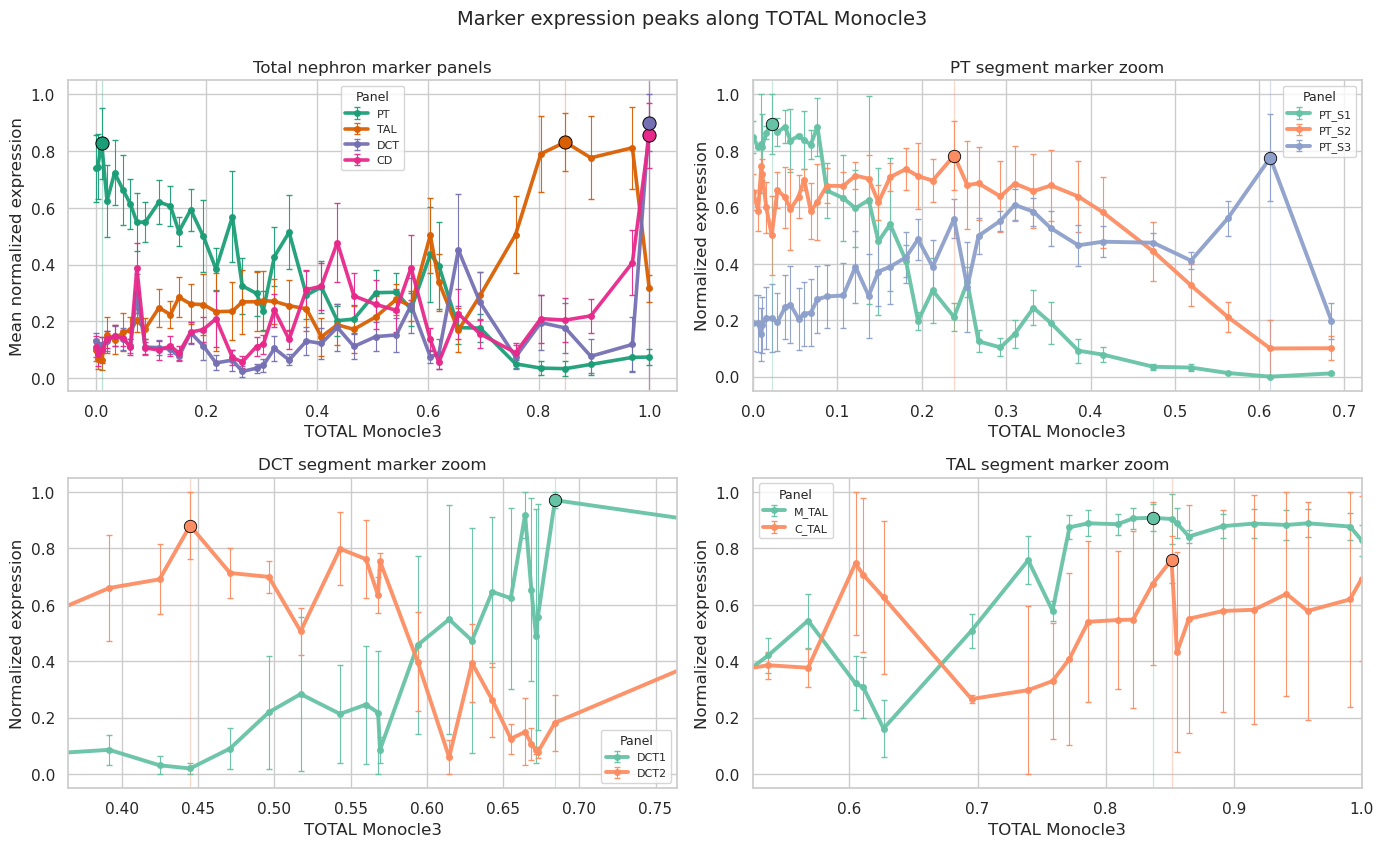

In [11]:
# Plot Monocle3 marker trends using the same four-panel layout.
monocle_marker_trends = plot_total_marker_trend_figure(
    monocle_loaded['TOTAL']['adata'],
    'total_monocle3',
    'TOTAL Monocle3',
    'total_monocle3_marker_trends.png',
)


## Method 4: Monocle with Harmonized UMAP


In [12]:
# Run Monocle3 as a fourth method by learning the trajectory graph on the existing harmonized UMAP.
monocle_harmony_umap_loaded = clone_preprocessed_continua()
for obj in monocle_harmony_umap_loaded.values():
    obj['gene_lookup'] = gene_lookup

_run_monocle3_total(monocle_harmony_umap_loaded, use_harmonized_umap=True)

method_runs = {
    'diffusion_pseudotime': dpt_loaded,
    'slingshot': slingshot_loaded,
    'monocle': monocle_loaded,
    'monocle_harmony_umap': monocle_harmony_umap_loaded,
}



Running Monocle3 on harmonized UMAP for TOTAL
total: using existing X_umap coordinates for Monocle3 graph learning
  |======================================================================| 100%
total: ordering Monocle3 on harmonized UMAP from 6 early root cells


,marker_panel,requested_gene,gene,present,view,method
0,PT,Slc34a1,Slc34a1,True,broad_nephron,TOTAL Monocle3 with harmonized UMAP
1,PT,Lrp2,Lrp2,True,broad_nephron,TOTAL Monocle3 with harmonized UMAP
2,PT,Slc5a12,Slc5a12,True,broad_nephron,TOTAL Monocle3 with harmonized UMAP
3,PT,Slc13a3,Slc13a3,True,broad_nephron,TOTAL Monocle3 with harmonized UMAP
4,PT,Slc22a6,Slc22a6,True,broad_nephron,TOTAL Monocle3 with harmonized UMAP
5,PT,Slc22a7,Slc22a7,True,broad_nephron,TOTAL Monocle3 with harmonized UMAP
6,PT,Aqp1,Aqp1,True,broad_nephron,TOTAL Monocle3 with harmonized UMAP
7,TAL,Umod,Umod,True,broad_nephron,TOTAL Monocle3 with harmonized UMAP
8,TAL,Slc12a1,Slc12a1,True,broad_nephron,TOTAL Monocle3 with harmonized UMAP
9,TAL,Cldn10,Cldn10,True,broad_nephron,TOTAL Monocle3 with harmonized UMAP


,marker_panel,requested_gene,gene,present,view,method
0,PT_S1,Slc5a2,Slc5a2,True,PT_zoom,TOTAL Monocle3 with harmonized UMAP
1,PT_S1,Slc5a12,Slc5a12,True,PT_zoom,TOTAL Monocle3 with harmonized UMAP
2,PT_S2,Slc22a8,Slc22a8,True,PT_zoom,TOTAL Monocle3 with harmonized UMAP
3,PT_S2,Slc22a6,Slc22a6,True,PT_zoom,TOTAL Monocle3 with harmonized UMAP
4,PT_S2,Slc13a3,Slc13a3,True,PT_zoom,TOTAL Monocle3 with harmonized UMAP
5,PT_S2,Slc22a2,Slc22a2,True,PT_zoom,TOTAL Monocle3 with harmonized UMAP
6,PT_S2,Slc34a1,Slc34a1,True,PT_zoom,TOTAL Monocle3 with harmonized UMAP
7,PT_S3,Slc7a13,Slc7a13,True,PT_zoom,TOTAL Monocle3 with harmonized UMAP
8,PT_S3,Slc5a8,Slc5a8,True,PT_zoom,TOTAL Monocle3 with harmonized UMAP
9,PT_S3,Slc38a3,Slc38a3,True,PT_zoom,TOTAL Monocle3 with harmonized UMAP


,marker_panel,gene,peak_pseudotime,peak_mean_expression,normalized_expression,view,method
0,PT_S1,Slc5a2,0.002627,2.371677,1.0,PT_zoom,TOTAL Monocle3 with harmonized UMAP
1,PT_S1,Slc5a12,0.126006,2.217736,1.0,PT_zoom,TOTAL Monocle3 with harmonized UMAP
2,PT_S2,Slc13a3,0.050898,2.127916,1.0,PT_zoom,TOTAL Monocle3 with harmonized UMAP
3,PT_S2,Slc22a6,0.050898,2.278020,1.0,PT_zoom,TOTAL Monocle3 with harmonized UMAP
4,PT_S2,Slc22a8,0.109231,2.493453,1.0,PT_zoom,TOTAL Monocle3 with harmonized UMAP
5,PT_S2,Slc34a1,0.142611,3.524533,1.0,PT_zoom,TOTAL Monocle3 with harmonized UMAP
6,PT_S2,Slc22a2,0.161993,1.679050,1.0,PT_zoom,TOTAL Monocle3 with harmonized UMAP
7,PT_S3,Pck1,0.142611,4.240129,1.0,PT_zoom,TOTAL Monocle3 with harmonized UMAP
8,PT_S3,Hao2,0.372882,1.600162,1.0,PT_zoom,TOTAL Monocle3 with harmonized UMAP
9,PT_S3,Acsm3,0.579511,2.278579,1.0,PT_zoom,TOTAL Monocle3 with harmonized UMAP


,marker_panel,requested_gene,gene,present,view,method
0,DCT1,Slc12a3,Slc12a3,True,DCT_zoom,TOTAL Monocle3 with harmonized UMAP
1,DCT1,Pvalb,Pvalb,True,DCT_zoom,TOTAL Monocle3 with harmonized UMAP
2,DCT2,Hsd11b2,Hsd11b2,True,DCT_zoom,TOTAL Monocle3 with harmonized UMAP
3,DCT2,Scnn1g,Scnn1g,True,DCT_zoom,TOTAL Monocle3 with harmonized UMAP
4,DCT2,Calb1,Calb1,True,DCT_zoom,TOTAL Monocle3 with harmonized UMAP


,marker_panel,gene,peak_pseudotime,peak_mean_expression,normalized_expression,view,method
0,DCT1,Slc12a3,0.777321,4.725061,1.0,DCT_zoom,TOTAL Monocle3 with harmonized UMAP
1,DCT1,Pvalb,0.778107,1.734419,1.0,DCT_zoom,TOTAL Monocle3 with harmonized UMAP
2,DCT2,Hsd11b2,0.941927,3.721447,1.0,DCT_zoom,TOTAL Monocle3 with harmonized UMAP
3,DCT2,Scnn1g,0.976738,1.632527,1.0,DCT_zoom,TOTAL Monocle3 with harmonized UMAP
4,DCT2,Calb1,0.986722,3.756673,1.0,DCT_zoom,TOTAL Monocle3 with harmonized UMAP


,marker_panel,requested_gene,gene,present,view,method
0,M_TAL,Umod,Umod,True,TAL_zoom,TOTAL Monocle3 with harmonized UMAP
1,M_TAL,Slc12a1,Slc12a1,True,TAL_zoom,TOTAL Monocle3 with harmonized UMAP
2,M_TAL,Kcnj1,Kcnj1,True,TAL_zoom,TOTAL Monocle3 with harmonized UMAP
3,M_TAL,Egf,Egf,True,TAL_zoom,TOTAL Monocle3 with harmonized UMAP
4,C_TAL,Cldn10,Cldn10,True,TAL_zoom,TOTAL Monocle3 with harmonized UMAP
5,C_TAL,Bcl6,Bcl6,True,TAL_zoom,TOTAL Monocle3 with harmonized UMAP
6,C_TAL,Nos1,None,False,TAL_zoom,TOTAL Monocle3 with harmonized UMAP


,marker_panel,gene,peak_pseudotime,peak_mean_expression,normalized_expression,view,method
0,C_TAL,Bcl6,0.491091,0.506669,1.0,TAL_zoom,TOTAL Monocle3 with harmonized UMAP
1,C_TAL,Cldn10,0.711999,1.640594,1.0,TAL_zoom,TOTAL Monocle3 with harmonized UMAP
2,M_TAL,Egf,0.688254,3.922213,1.0,TAL_zoom,TOTAL Monocle3 with harmonized UMAP
3,M_TAL,Slc12a1,0.688254,3.617826,1.0,TAL_zoom,TOTAL Monocle3 with harmonized UMAP
4,M_TAL,Umod,0.773139,5.646257,1.0,TAL_zoom,TOTAL Monocle3 with harmonized UMAP
5,M_TAL,Kcnj1,0.798688,1.795785,1.0,TAL_zoom,TOTAL Monocle3 with harmonized UMAP


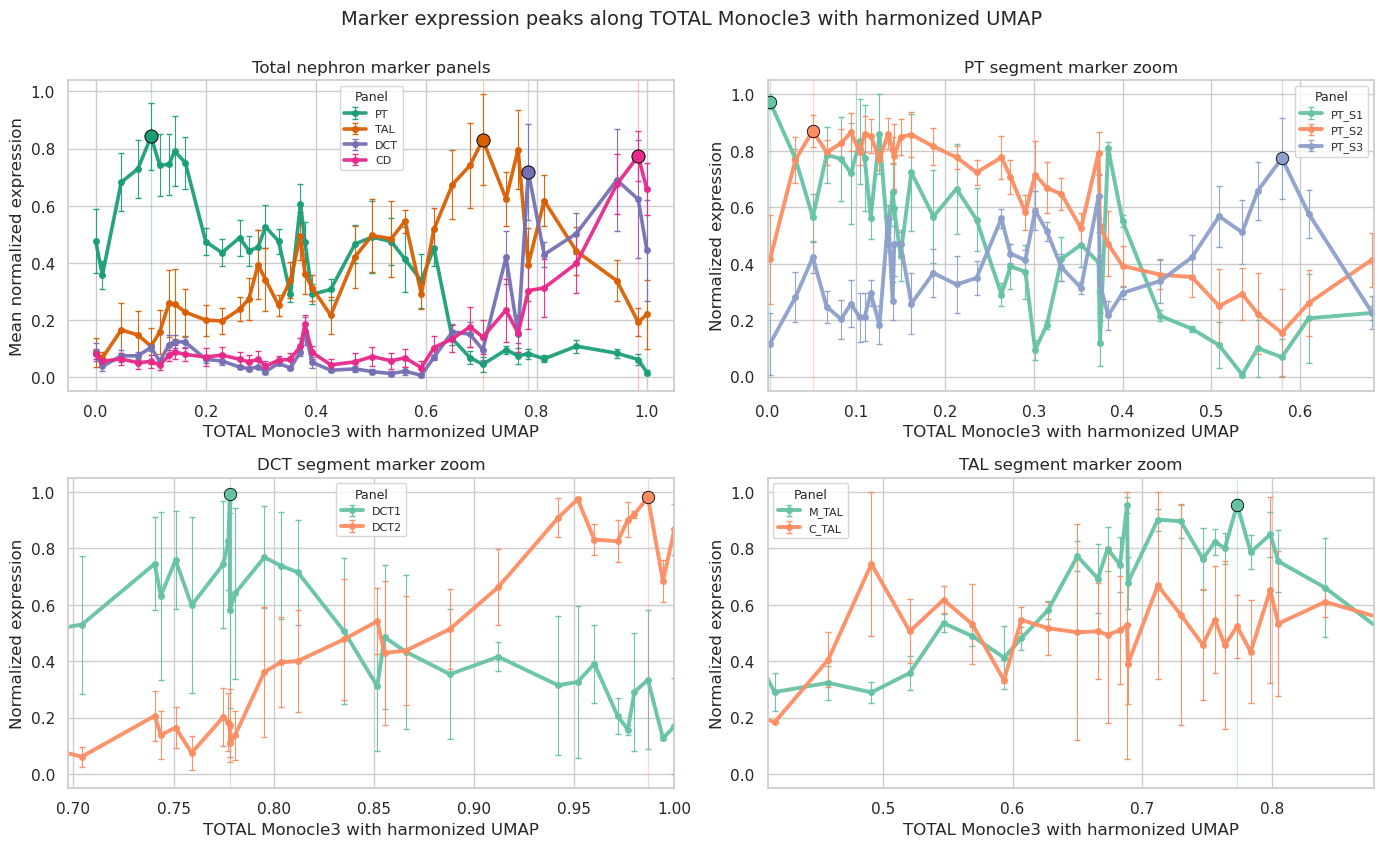

In [13]:
# Plot Monocle3-on-harmonized-UMAP marker trends using the same four-panel layout.
monocle_harmony_umap_marker_trends = plot_total_marker_trend_figure(
    monocle_harmony_umap_loaded['TOTAL']['adata'],
    'total_monocle3_harmony_umap',
    'TOTAL Monocle3 with harmonized UMAP',
    'total_monocle3_harmony_umap_marker_trends.png',
)


## Method Scoring


In [14]:
# Score each method after its pseudotime columns have been added.
all_method_summaries = []
all_marker_summaries = []

for method_key, loaded in method_runs.items():
    for continuum, obj in loaded.items():
        print('\n' + '=' * 80)
        print(f'Scoring {method_key} for {continuum}')
        adata = obj['adata']
        config = obj['config']
        prefix = config['prefix']
        marker_axis = adata.obs[f'{prefix}_marker_axis'].to_numpy(dtype=float)
        saved_ps = adata.obs[f'{prefix}_pseudospace'].to_numpy(dtype=float)
        expected_markers = obj['expected_markers']

        method_rows = []
        marker_rows = []
        for method in obj['method_cols']:
            values = adata.obs[method].to_numpy(dtype=float)
            valid_marker = np.isfinite(values) & np.isfinite(marker_axis)
            valid_saved = np.isfinite(values) & np.isfinite(saved_ps)

            gene_rows = []
            for row in expected_markers.to_dict('records'):
                gene = row['gene']
                if gene not in adata.var_names:
                    continue
                expr_col = adata.X[:, adata.var_names.get_loc(gene)]
                expr = expr_col.toarray().ravel() if sparse.issparse(expr_col) else np.asarray(expr_col).ravel()
                expr = expr.astype(float)
                valid_expr = np.isfinite(values) & np.isfinite(expr)
                corr = spearmanr(values[valid_expr], expr[valid_expr]).correlation if valid_expr.sum() >= 20 else np.nan
                gene_rows.append({
                    'method_family': method_key,
                    'continuum': continuum,
                    'method': method,
                    'gene': gene,
                    'role': row['role'],
                    'expected_direction': row['expected_direction'],
                    'spearman_expr_vs_pseudotime': corr,
                    'matches_expected': bool(np.isfinite(corr) and np.sign(corr) == row['expected_sign']),
                })

            gene_scores = pd.DataFrame(gene_rows)
            if not gene_scores.empty:
                marker_rows.append(gene_scores)

            method_rows.append({
                'method_family': method_key,
                'continuum': prefix.upper(),
                'method': method,
                'n_cells_scored': int(np.isfinite(values).sum()),
                'spearman_with_marker_axis': spearmanr(values[valid_marker], marker_axis[valid_marker]).correlation if valid_marker.sum() >= 10 else np.nan,
                'spearman_with_saved_marker_pseudospace': spearmanr(values[valid_saved], saved_ps[valid_saved]).correlation if valid_saved.sum() >= 10 else np.nan,
                'marker_gene_direction_fraction': gene_scores['matches_expected'].mean() if len(gene_scores) else np.nan,
                'mean_abs_marker_gene_spearman': gene_scores['spearman_expr_vs_pseudotime'].abs().mean() if len(gene_scores) else np.nan,
                'note': obj['method_notes'].get(method, ''),
            })

        summary = pd.DataFrame(method_rows)
        marker_summary = pd.concat(marker_rows, ignore_index=True) if marker_rows else pd.DataFrame()
        display(summary.sort_values(['marker_gene_direction_fraction', 'spearman_with_marker_axis'], ascending=False))


        all_method_summaries.append(summary)
        all_marker_summaries.append(marker_summary if not marker_summary.empty else marker_summary)

method_summary = pd.concat(all_method_summaries, ignore_index=True)
marker_gene_direction_summary = pd.concat([df for df in all_marker_summaries if not df.empty], ignore_index=True)
display(method_summary.sort_values(['continuum', 'marker_gene_direction_fraction', 'spearman_with_marker_axis'], ascending=[True, False, False]))



Scoring diffusion_pseudotime for TOTAL


,method_family,continuum,method,n_cells_scored,spearman_with_marker_axis,spearman_with_saved_marker_pseudospace,marker_gene_direction_fraction,mean_abs_marker_gene_spearman,note
0,diffusion_pseudotime,TOTAL,total_marker_axis_score,45753,0.999875,1.000000,1.000000,0.407386,marker-axis reference from early and late mark...
1,diffusion_pseudotime,TOTAL,total_saved_marker_pseudospace,45753,0.999875,1.000000,1.000000,0.407386,saved marker-derived pseudospace oriented to m...
3,diffusion_pseudotime,TOTAL,total_scanpy_dpt,45753,0.819285,0.818945,0.888889,0.358240,"Scanpy DPT on X_harmony, rooted at lowest mark..."
2,diffusion_pseudotime,TOTAL,total_diffmap_component_1,45753,0.804075,0.803769,0.888889,0.354303,"Scanpy diffusion map component 1, oriented to ..."



Scoring slingshot for TOTAL


,method_family,continuum,method,n_cells_scored,spearman_with_marker_axis,spearman_with_saved_marker_pseudospace,marker_gene_direction_fraction,mean_abs_marker_gene_spearman,note
0,slingshot,TOTAL,total_marker_axis_score,45753,0.999875,1.000000,1.000000,0.407386,marker-axis reference from early and late mark...
1,slingshot,TOTAL,total_saved_marker_pseudospace,45753,0.999875,1.000000,1.000000,0.407386,saved marker-derived pseudospace oriented to m...
2,slingshot,TOTAL,total_slingshot,45753,0.809205,0.808878,0.888889,0.346831,"Slingshot ran on 45,753/45,753 cells using X_h..."



Scoring slingshot for PT


...


Scoring monocle_harmony_umap for TAL


,method_family,continuum,method,n_cells_scored,spearman_with_marker_axis,spearman_with_saved_marker_pseudospace,marker_gene_direction_fraction,mean_abs_marker_gene_spearman,note
0,monocle_harmony_umap,TAL,tal_marker_axis_score,14472,0.999875,1.0,1.0,0.663566,marker-axis reference from early and late mark...
1,monocle_harmony_umap,TAL,tal_saved_marker_pseudospace,14472,0.999875,1.0,1.0,0.663566,saved marker-derived pseudospace oriented to m...



Scoring monocle_harmony_umap for DCT


,method_family,continuum,method,n_cells_scored,spearman_with_marker_axis,spearman_with_saved_marker_pseudospace,marker_gene_direction_fraction,mean_abs_marker_gene_spearman,note
0,monocle_harmony_umap,DCT,dct_marker_axis_score,4468,0.999874,1.0,1.0,0.607227,marker-axis reference from early and late mark...
1,monocle_harmony_umap,DCT,dct_saved_marker_pseudospace,4468,0.999874,1.0,1.0,0.607227,saved marker-derived pseudospace oriented to m...


,method_family,continuum,method,n_cells_scored,spearman_with_marker_axis,spearman_with_saved_marker_pseudospace,marker_gene_direction_fraction,mean_abs_marker_gene_spearman,note
11,slingshot,DCT,dct_marker_axis_score,4468,0.999874,1.000000,1.000000,0.607227,marker-axis reference from early and late mark...
12,slingshot,DCT,dct_saved_marker_pseudospace,4468,0.999874,1.000000,1.000000,0.607227,saved marker-derived pseudospace oriented to m...
20,monocle,DCT,dct_marker_axis_score,4468,0.999874,1.000000,1.000000,0.607227,marker-axis reference from early and late mark...
21,monocle,DCT,dct_saved_marker_pseudospace,4468,0.999874,1.000000,1.000000,0.607227,saved marker-derived pseudospace oriented to m...
29,monocle_harmony_umap,DCT,dct_marker_axis_score,4468,0.999874,1.000000,1.000000,0.607227,marker-axis reference from early and late mark...
30,monocle_harmony_umap,DCT,dct_saved_marker_pseudospace,4468,0.999874,1.000000,1.000000,0.607227,saved marker-derived pseudospace oriented to m...
7,slingshot,PT,pt_marker_axis_score,20405,0.999875,1.000000,1.000000,0.511747,marker-axis reference from early and late mark...
8,slingshot,PT,pt_saved_marker_pseudospace,20405,0.999875,1.000000,1.000000,0.511747,saved marker-derived pseudospace oriented to m...
16,monocle,PT,pt_marker_axis_score,20405,0.999875,1.000000,1.000000,0.511747,marker-axis reference from early and late mark...
17,monocle,PT,pt_saved_marker_pseudospace,20405,0.999875,1.000000,1.000000,0.511747,saved marker-derived pseudospace oriented to m...


## Visualization


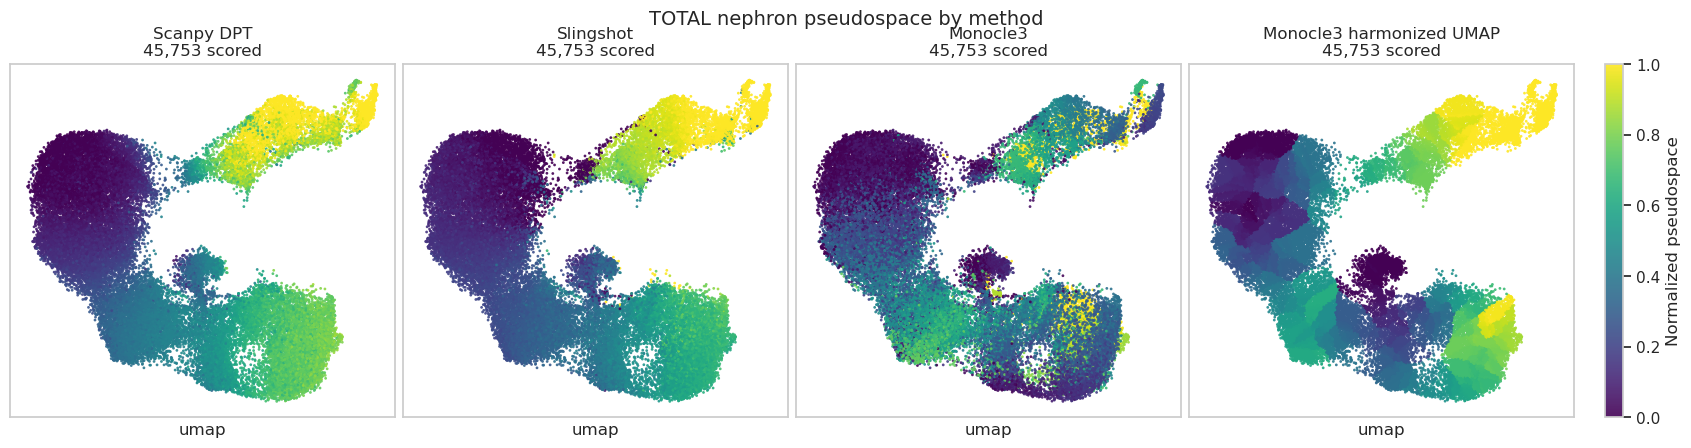

,x,y,n,spearman
0,Scanpy DPT,Slingshot,45753,0.948441
1,Scanpy DPT,Monocle3,45753,0.671202
2,Scanpy DPT,Monocle3 harmonized UMAP,45753,0.829533
3,Slingshot,Monocle3,45753,0.665393
4,Slingshot,Monocle3 harmonized UMAP,45753,0.779745
5,Monocle3,Monocle3 harmonized UMAP,45753,0.608024


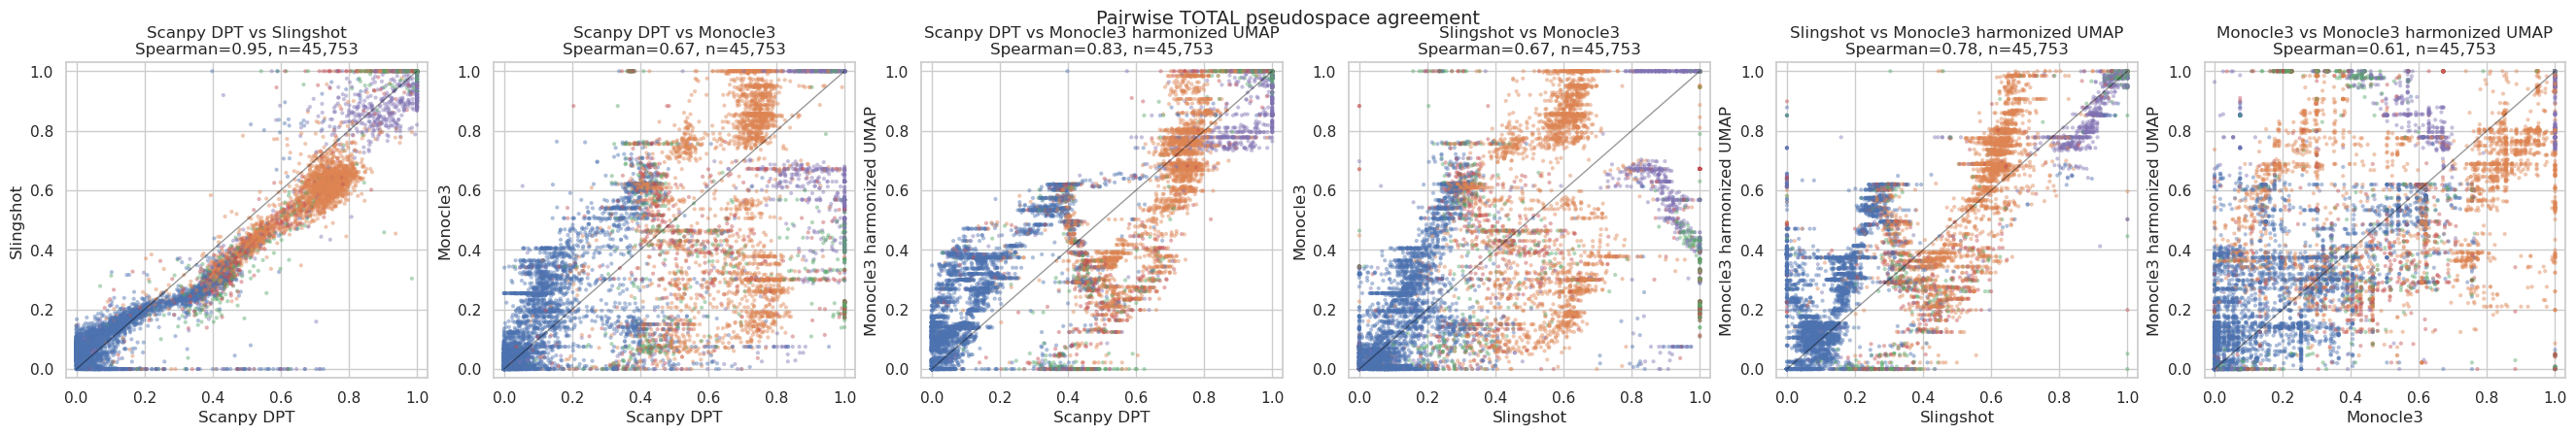

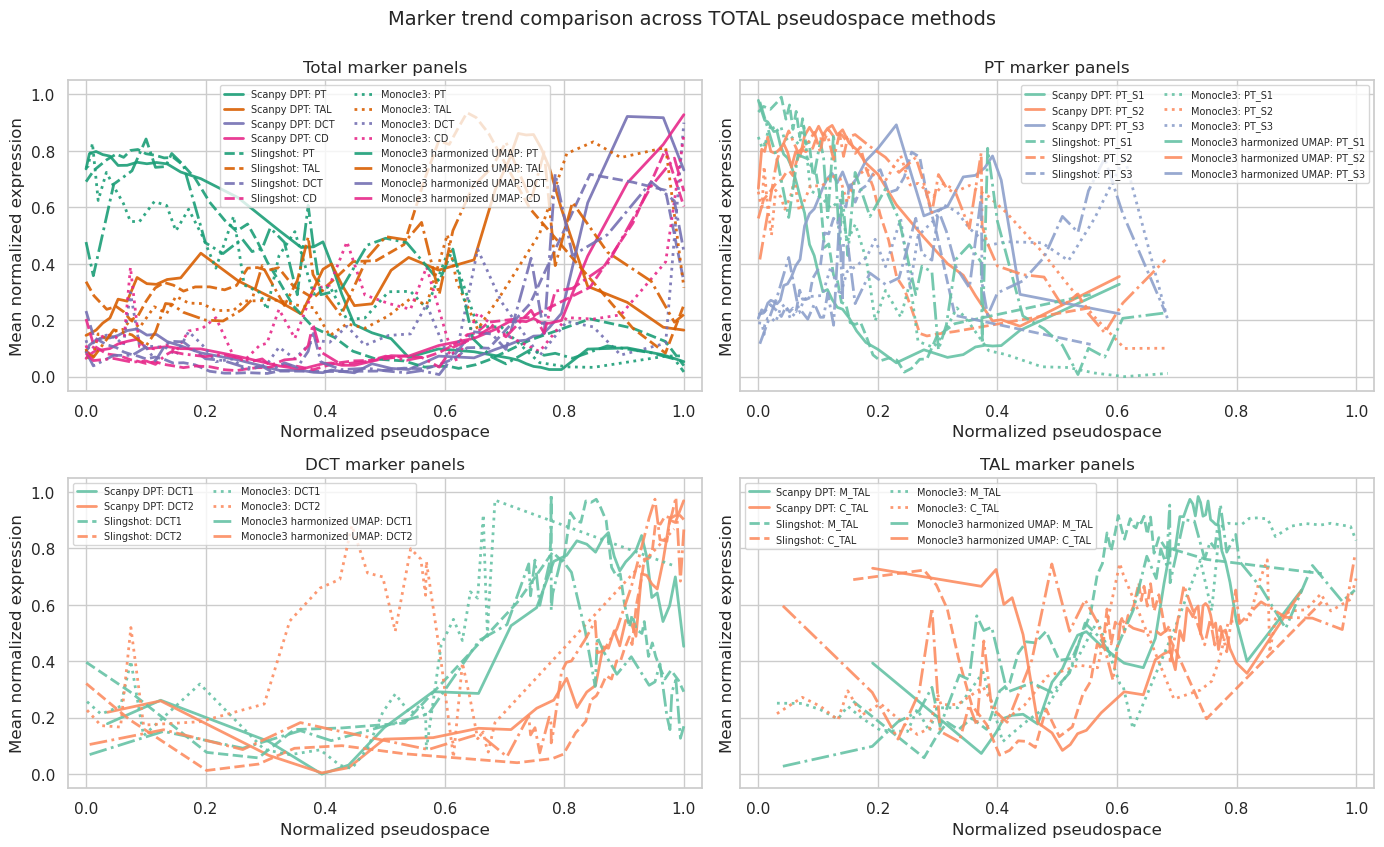

In [15]:
# Compare TOTAL pseudospace methods with two compact figures.
method_specs = [
    ('Scanpy DPT', dpt_loaded['TOTAL']['adata'], 'total_scanpy_dpt'),
    ('Slingshot', slingshot_loaded['TOTAL']['adata'], 'total_slingshot'),
    ('Monocle3', monocle_loaded['TOTAL']['adata'], 'total_monocle3'),
    ('Monocle3 harmonized UMAP', monocle_harmony_umap_loaded['TOTAL']['adata'], 'total_monocle3_harmony_umap'),
]
method_specs = [spec for spec in method_specs if spec[2] in spec[1].obs]
if len(method_specs) < 2:
    raise ValueError('Need at least two TOTAL pseudotime methods to compare')

base_adata = dpt_loaded['TOTAL']['adata']
method_df = pd.DataFrame(index=base_adata.obs_names)
for label, adata, col in method_specs:
    values = pd.Series(adata.obs[col].to_numpy(dtype=float), index=adata.obs_names, name=label)
    method_df[label] = values.reindex(method_df.index)

marker_call_col = 'total_segment_marker_call'
if marker_call_col in base_adata.obs.columns:
    method_df['segment'] = base_adata.obs[marker_call_col].astype(str).reindex(method_df.index)
else:
    method_df['segment'] = 'all'

# Figure 1: same embedding, colored by each method's TOTAL pseudospace.
basis = None
for key in ['X_umap_harmony_total', 'X_umap_harmony', 'X_umap']:
    if key in base_adata.obsm:
        basis = key
        break
if basis is None:
    for key in base_adata.obsm.keys():
        if str(key).startswith('X_umap'):
            basis = str(key)
            break
if basis is None:
    preferred_reps = ['X_pca_harmony_total', 'X_pca_harmony', 'X_harmony', 'X_pca']
    use_rep = next((rep for rep in preferred_reps if rep in base_adata.obsm), None)
    if use_rep is None:
        sc.pp.pca(base_adata, n_comps=min(N_PCS_FALLBACK, base_adata.n_vars - 1), random_state=RANDOM_STATE)
        use_rep = 'X_pca'
    sc.pp.neighbors(base_adata, n_neighbors=N_NEIGHBORS, use_rep=use_rep, key_added='method_compare_neighbors', random_state=RANDOM_STATE)
    sc.tl.umap(base_adata, neighbors_key='method_compare_neighbors', random_state=RANDOM_STATE)
    basis = 'X_umap'

embedding = pd.DataFrame(base_adata.obsm[basis][:, :2], index=base_adata.obs_names, columns=['x', 'y'])
plot_df = embedding.join(method_df)

fig, axes = plt.subplots(1, len(method_specs), figsize=(4.2 * len(method_specs), 4.2), constrained_layout=True)
axes = np.atleast_1d(axes)
for ax, (label, _, _) in zip(axes, method_specs):
    valid = plot_df[label].notna()
    ax.scatter(plot_df.loc[~valid, 'x'], plot_df.loc[~valid, 'y'], s=3, color='lightgray', alpha=0.35, linewidths=0)
    sca = ax.scatter(
        plot_df.loc[valid, 'x'],
        plot_df.loc[valid, 'y'],
        c=plot_df.loc[valid, label],
        cmap='viridis',
        vmin=0,
        vmax=1,
        s=4 if base_adata.n_obs >= 5000 else 9,
        alpha=0.9,
        linewidths=0,
    )
    ax.set_title(f'{label}\n{valid.sum():,} scored')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel(basis.replace('X_', ''))
    ax.set_ylabel('')
fig.colorbar(sca, ax=axes, label='Normalized pseudospace', fraction=0.025, pad=0.02)
fig.suptitle('TOTAL nephron pseudospace by method', y=1.03, fontsize=14)
fig.savefig(OUTPUT_DIR / 'total_method_pseudospace_umap_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

# Figure 2: pairwise agreement between methods on cells scored by both methods.
pair_rows = []
method_labels = [label for label, _, _ in method_specs]
for i, x_label in enumerate(method_labels):
    for y_label in method_labels[i + 1:]:
        valid = method_df[[x_label, y_label]].notna().all(axis=1)
        corr = spearmanr(method_df.loc[valid, x_label], method_df.loc[valid, y_label]).correlation if valid.sum() >= 20 else np.nan
        pair_rows.append({'x': x_label, 'y': y_label, 'n': int(valid.sum()), 'spearman': corr})
pair_summary = pd.DataFrame(pair_rows)
display(pair_summary)

fig, axes = plt.subplots(1, len(pair_rows), figsize=(4.4 * len(pair_rows), 4.2), constrained_layout=True)
axes = np.atleast_1d(axes)
for ax, row in zip(axes, pair_rows):
    valid = method_df[[row['x'], row['y']]].notna().all(axis=1)
    sample = method_df.loc[valid, [row['x'], row['y'], 'segment']].copy()
    if len(sample) > 8000:
        sample = sample.sample(8000, random_state=RANDOM_STATE)
    sns.scatterplot(
        data=sample,
        x=row['x'],
        y=row['y'],
        hue='segment' if sample['segment'].nunique() > 1 else None,
        s=9,
        alpha=0.45,
        linewidth=0,
        ax=ax,
        legend=False,
    )
    ax.plot([0, 1], [0, 1], color='black', linewidth=1, alpha=0.4)
    ax.set_xlim(-0.03, 1.03)
    ax.set_ylim(-0.03, 1.03)
    ax.set_title(f"{row['x']} vs {row['y']}\nSpearman={row['spearman']:.2f}, n={row['n']:,}")
    ax.set_xlabel(row['x'])
    ax.set_ylabel(row['y'])
fig.suptitle('Pairwise TOTAL pseudospace agreement', y=1.03, fontsize=14)
fig.savefig(OUTPUT_DIR / 'total_method_pairwise_agreement.png', dpi=200, bbox_inches='tight')
plt.show()

# Figure 3: overlay the four-panel marker-trend summaries across methods.
def plot_total_marker_trend_method_comparison(method_specs, output_name):
    broad_marker_panels = {
        'PT': BROAD_SEGMENT_MARKERS['PT'],
        'TAL': BROAD_SEGMENT_MARKERS['TAL'],
        'DCT': BROAD_SEGMENT_MARKERS['DCT'],
        'CD': BROAD_SEGMENT_MARKERS['CNT_CD'],
    }
    zoom_marker_panels = {
        'PT': CONTINUUM_CONFIGS['PT']['segment_markers'],
        'DCT': CONTINUUM_CONFIGS['DCT']['segment_markers'],
        'TAL': CONTINUUM_CONFIGS['TAL']['segment_markers'],
    }
    views = [('Total', broad_marker_panels), ('PT', zoom_marker_panels['PT']), ('DCT', zoom_marker_panels['DCT']), ('TAL', zoom_marker_panels['TAL'])]
    method_styles = dict(zip([label for label, _, _ in method_specs], ['-', '--', ':', '-.']))

    fig, axes = plt.subplots(2, 2, figsize=(14, 8.5), sharey=True)
    for ax, (view_name, marker_panels) in zip(axes.ravel(), views):
        palette = dict(zip(marker_panels, sns.color_palette('Dark2' if view_name == 'Total' else 'Set2', n_colors=len(marker_panels))))
        for method_label, adata, pseudotime_col in method_specs:
            trend_adata = adata if view_name == 'Total' else adata[adata.obs['total_segment_marker_call'].eq(view_name)].copy()
            _, _, _, aggregate_df, _ = _build_marker_trends_for_method(trend_adata, pseudotime_col, marker_panels)
            for marker_panel in marker_panels:
                panel_df = aggregate_df.loc[aggregate_df['marker_panel'] == marker_panel].sort_values('pseudotime')
                ax.plot(
                    panel_df['pseudotime'],
                    panel_df['normalized_expression'],
                    color=palette[marker_panel],
                    linestyle=method_styles[method_label],
                    linewidth=2.0,
                    alpha=0.9,
                    label=f'{method_label}: {marker_panel}',
                )
        ax.set_title(f'{view_name} marker panels')
        ax.set_xlabel('Normalized pseudospace')
        ax.set_ylabel('Mean normalized expression')
        ax.set_xlim(-0.03, 1.03)
        ax.set_ylim(-0.05, 1.05)
        ax.legend(fontsize=7, ncols=2)
    fig.suptitle('Marker trend comparison across TOTAL pseudospace methods', y=0.995, fontsize=14)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / output_name, dpi=200, bbox_inches='tight')
    plt.show()


plot_total_marker_trend_method_comparison(
    method_specs,
    'total_method_marker_trend_comparison.png',
)


## Save Pseudotime Outputs


In [16]:
# Save compact AnnData objects for each TOTAL pseudotime method.
def save_total_pseudotime_anndata(source_adata, pseudotime_col, output_path):
    if pseudotime_col not in source_adata.obs.columns:
        raise KeyError(f'Missing required pseudotime column: {pseudotime_col}')

    out = adata_all_expression_filtered.copy()
    shared = out.obs_names.intersection(source_adata.obs_names)
    if pseudotime_col not in out.obs.columns:
        out.obs[pseudotime_col] = np.nan
    out.obs.loc[shared, pseudotime_col] = source_adata.obs.loc[shared, pseudotime_col].to_numpy(dtype=float)

    segment_col = 'total_segment_marker_call'
    if segment_col in source_adata.obs.columns:
        if segment_col not in out.obs.columns:
            out.obs[segment_col] = pd.NA
        out.obs.loc[shared, segment_col] = source_adata.obs.loc[shared, segment_col].astype(str).values

    keep_obs = [
        col for col in [
            'sample',
            'species',
            'condition',
            'broad_tubule_marker_call',
            'total_segment_marker_call',
            pseudotime_col,
        ]
        if col in out.obs.columns
    ]
    out.obs = out.obs[keep_obs].copy()
    out.write(output_path)
    print(f'Saved {pseudotime_col} AnnData to: {output_path.relative_to(PROJECT_DIR)}')
    return out


saved_pseudotime_anndatas = {
    'scanpy_dpt': save_total_pseudotime_anndata(
        dpt_loaded['TOTAL']['adata'],
        'total_scanpy_dpt',
        OUTPUT_DIR / 'all_tubules_scanpy_dpt.h5ad',
    ),
    'slingshot': save_total_pseudotime_anndata(
        slingshot_loaded['TOTAL']['adata'],
        'total_slingshot',
        OUTPUT_DIR / 'all_tubules_slingshot.h5ad',
    ),
    'monocle3': save_total_pseudotime_anndata(
        monocle_loaded['TOTAL']['adata'],
        'total_monocle3',
        OUTPUT_DIR / 'all_tubules_monocle3.h5ad',
    ),
    'monocle3_harmony_umap': save_total_pseudotime_anndata(
        monocle_harmony_umap_loaded['TOTAL']['adata'],
        'total_monocle3_harmony_umap',
        OUTPUT_DIR / 'all_tubules_monocle3_harmony_umap.h5ad',
    ),
}

saved_pseudotime_anndatas


Saved total_scanpy_dpt AnnData to: data/pseudspace_analysis/all_tubules_scanpy_dpt.h5ad
Saved total_slingshot AnnData to: data/pseudspace_analysis/all_tubules_slingshot.h5ad
Saved total_monocle3 AnnData to: data/pseudspace_analysis/all_tubules_monocle3.h5ad
Saved total_monocle3_harmony_umap AnnData to: data/pseudspace_analysis/all_tubules_monocle3_harmony_umap.h5ad


{'scanpy_dpt': AnnData object with n_obs × n_vars = 45753 × 9610
     obs: 'sample', 'species', 'condition', 'total_segment_marker_call', 'total_scanpy_dpt'
     var: 'mt', 'ribo', 'exclude_from_harmony_hvg', 'hvg_condition_count', 'highly_variable_for_harmony', 'forced_harmony_marker', 'n_tubules_expressed', 'total_counts', 'passes_expression_count_filter'
     uns: 'condition_colors', 'log1p', 'neighbors', 'sample_colors', 'species_colors', 'umap', 'raw_counts_layer', 'normalization'
     obsm: 'X_harmony', 'X_pca', 'X_umap'
     layers: 'counts', 'lognorm'
     obsp: 'connectivities', 'distances',
 'slingshot': AnnData object with n_obs × n_vars = 45753 × 9610
     obs: 'sample', 'species', 'condition', 'total_segment_marker_call', 'total_slingshot'
     var: 'mt', 'ribo', 'exclude_from_harmony_hvg', 'hvg_condition_count', 'highly_variable_for_harmony', 'forced_harmony_marker', 'n_tubules_expressed', 'total_counts', 'passes_expression_count_filter'
     uns: 'condition_colors', 'log